# Data Science for Snow & Ice Spectral Modelling
## A Training Manual: From Sampling to Inversion

### Why this notebook exists

Satellite remote sensing of snow and ice requires solving an **inverse problem**:
given a measured reflectance spectrum, determine the physical properties of the
surface — grain size, impurity loading, density, layer structure. The forward
direction is handled by radiative transfer models like BioSNICAR, which solve
the equations of light scattering and absorption through a layered snowpack.
But forward models are too slow (~0.5 s per evaluation) for the millions of
evaluations needed during optimisation and uncertainty quantification.

This notebook teaches **every data-science concept** behind the BioSNICAR
emulator and inversion scheme, from first principles, using toy examples that
run without BioSNICAR installed. Each technique is motivated by a concrete
physical problem, demonstrated on a toy snow/ice spectrum, and then connected
to the exact line of BioSNICAR source code where it is used.

### Structure

| Act | Theme | Sections | Core question |
|-----|-------|----------|---------------|
| I   | Sampling & the Curse of Dimensionality | 1 – 4 | How do we efficiently explore parameter space? |
| II  | Dimensionality Reduction & Emulation | 5 – 9 | How do we make the forward model fast enough? |
| III | Cost Functions & Optimisation | 10 – 16 | How do we find the best-fit parameters? |
| IV  | Uncertainty Quantification | 17 – 22 | How confident should we be in the answer? |
| V   | Putting It All Together | 23 – 25 | Full retrieval pipeline, end to end |

### How to use this notebook

- **Run cells in order** — later sections depend on objects built earlier.
- **BioSNICAR connection** boxes after each section map the toy concept to
  the exact BioSNICAR module, function, and line number.
- **Exercises** at section ends invite you to experiment further.
- Section 25 (capstone) optionally runs a real BioSNICAR retrieval.

> **Dependencies**: `numpy`, `scipy`, `matplotlib`, `scikit-learn`.
> `emcee` is optional (a built-in Metropolis-Hastings sampler is provided as
> fallback).  Section 25 (capstone) optionally uses `biosnicar`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers '3d' projection
from matplotlib import cm
from scipy import optimize, linalg, stats
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
import warnings, time

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(42)

# Plotting defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "font.size": 9,
    "legend.fontsize": 8,
    "figure.figsize": (8, 4),
})

print("Setup complete.")


Setup complete.


---
# Act I: Sampling & the Curse of Dimensionality

## Section 1 — The Forward-Model Problem

### What is a forward model?

A **forward model** is a function that maps *physical parameters* (things we
want to know) to *observables* (things we can measure). In cryospheric remote
sensing the parameters describe the snowpack — grain size, density, impurity
concentration, layer thickness — and the observable is the **spectral albedo**:
the fraction of incoming sunlight reflected at each wavelength.

$$\alpha(\lambda) = f(r_{\mathrm{eff}},\; \rho,\; c_{\mathrm{imp}},\; \mathrm{d}z,\; \theta_s,\; \ldots)$$

where $r_{\mathrm{eff}}$ is effective grain radius, $\rho$ is density,
$c_{\mathrm{imp}}$ is impurity concentration, $\mathrm{d}z$ is layer thickness,
and $\theta_s$ is solar zenith angle.

### Why does snow albedo look the way it does?

Snow and ice albedo is controlled by two competing processes:

1. **Scattering** at grain boundaries redirects photons back out of the snowpack.
   More grain boundaries (finer snow) = more scattering = higher albedo.
2. **Absorption** by ice and impurities removes photons.
   Ice absorption increases steeply with wavelength above ~0.7 µm, creating
   the characteristic NIR rolloff and the discrete water-ice absorption bands
   at ~1.03, 1.27, 1.50, and 2.0 µm.

Grain size controls the **path length** between scattering events. Coarser grains
mean longer paths through ice, so more absorption in the NIR — but the visible
is barely affected because ice is almost transparent at those wavelengths.

Impurities (black carbon, dust, algae) absorb strongly in the **visible** but
are spectrally flat or decreasing into the NIR. Their effect is concentrated
below ~0.7 µm.

### The BioSNICAR forward model

BioSNICAR solves this physics rigorously via a multi-layer adding-doubling
radiative transfer scheme:

1. **Pre-computed Mie/geometric-optics lookup tables** provide single-scattering
   properties (extinction, SSA, asymmetry parameter) from grain size and
   refractive indices
   (`biosnicar/optical_properties/column_OPs.py:get_layer_OPs`)
2. **Impurity mixing** adds absorbers using mass-absorption coefficients
   (`biosnicar/optical_properties/column_OPs.py:mix_in_impurities`)
3. **Adding-doubling solver** propagates light through layers with
   Fresnel reflection at the surface
   (`biosnicar/rt_solvers/adding_doubling_solver.py`)
4. **Orchestrator** ties it together
   (`biosnicar/drivers/run_model.py:run_model`)

A single evaluation takes ~0.5 seconds. This is fine for one-off predictions
but far too slow for inverse problems (which need millions of evaluations).
The entire purpose of Acts I–II is to build a **fast surrogate** (emulator)
that replaces this 0.5 s call with a ~50 µs neural network prediction.

### Our toy spectrum

We define a simplified 2-parameter function that captures the essential
spectral physics:

- **Flat, high visible region** (~0.3–0.7 µm): clean snow reflects >95 %
- **Steep NIR rolloff** beyond 0.7 µm due to increasing ice absorption
- **Water-ice absorption bands** at ~1.03, 1.27, 1.50, and 2.0 µm
- **Grain-size effect**: coarser grains deepen NIR absorption (VIS barely changes)
- **Impurity effect**: darkens the visible while barely touching the NIR

In [2]:
# --- Toy forward model ---------------------------------------------------
WAVELENGTH = np.linspace(0.3, 2.5, 50)   # 50 bands, 0.3–2.5 µm

def toy_spectrum(grain_size, impurity, wavelength=WAVELENGTH):
    """Snow/ice-like 2-parameter spectrum.

    Parameters
    ----------
    grain_size : float in [0, 1]
        0 = fine snow (~100 µm), 1 = coarse glacier ice (~2000 µm).
    impurity : float in [0, 1]
        0 = clean, 1 = heavily loaded (proxy for BC / algae).
    wavelength : array
        Wavelength grid in µm.

    Returns
    -------
    albedo : array, same shape as wavelength, clipped to [0, 1]
    """
    # Visible plateau (flat and high, slightly lower for coarse grains)
    vis_albedo = 0.96 - 0.12 * grain_size

    # Continuum rolloff beyond ~0.7 µm (ice absorption increasing with λ)
    beyond_knee = np.maximum(wavelength - 0.7, 0)
    decay = (0.6 + 1.8 * grain_size) * beyond_knee ** 1.8

    # Water-ice absorption bands (Gaussian dips)
    band_1  = (0.18 + 0.25 * grain_size) * np.exp(-((wavelength - 1.03) / 0.08)**2)
    band_13 = (0.06 + 0.10 * grain_size) * np.exp(-((wavelength - 1.25) / 0.04)**2)
    band_15 = (0.55 + 0.40 * grain_size) * np.exp(-((wavelength - 1.50) / 0.12)**2)
    band_2  = (0.40 + 0.35 * grain_size) * np.exp(-((wavelength - 2.00) / 0.09)**2)

    # Impurity darkening (concentrated in visible, exponential decay into NIR)
    imp_effect = impurity * 0.65 * np.exp(-(wavelength - 0.3) / 0.35)

    albedo = vis_albedo - decay - band_1 - band_13 - band_15 - band_2 - imp_effect
    return np.clip(albedo, 0.0, 1.0)

print(f"Wavelength grid: {len(WAVELENGTH)} bands, "
      f"{WAVELENGTH[0]:.1f}–{WAVELENGTH[-1]:.1f} µm")


Wavelength grid: 50 bands, 0.3–2.5 µm


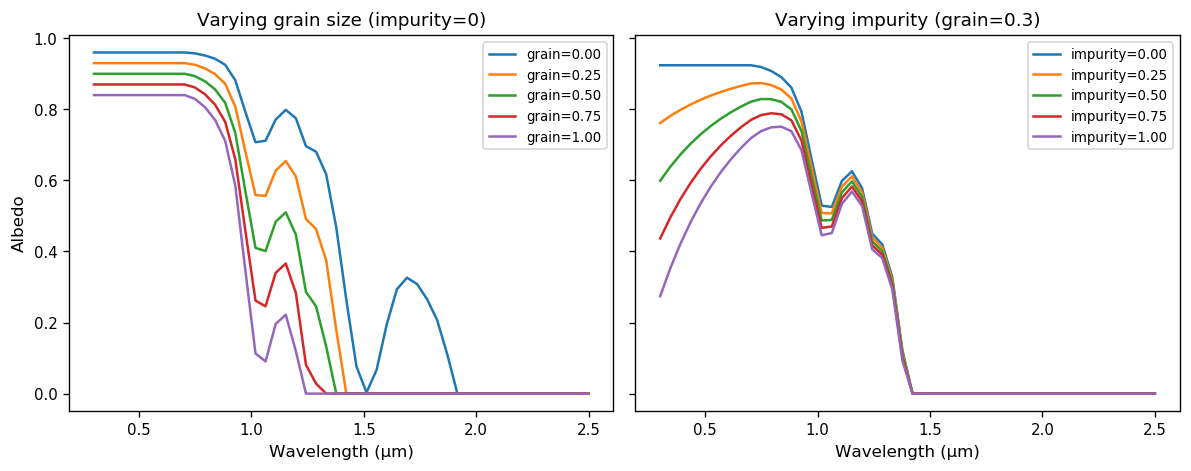

In [3]:
# --- Visualise a family of spectra ----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Vary grain size
for gs in [0.0, 0.25, 0.5, 0.75, 1.0]:
    axes[0].plot(WAVELENGTH, toy_spectrum(gs, 0.0),
                 label=f"grain={gs:.2f}")
axes[0].set(title="Varying grain size (impurity=0)",
            xlabel="Wavelength (µm)", ylabel="Albedo")
axes[0].legend()

# Vary impurity
for imp in [0.0, 0.25, 0.5, 0.75, 1.0]:
    axes[1].plot(WAVELENGTH, toy_spectrum(0.3, imp),
                 label=f"impurity={imp:.2f}")
axes[1].set(title="Varying impurity (grain=0.3)",
            xlabel="Wavelength (µm)")
axes[1].legend()

plt.tight_layout()
plt.show()


> **BioSNICAR connection** — The real forward model lives in
> `biosnicar/drivers/run_model.py`. It accepts keyword overrides like
> `rds` (grain radius, µm), `rho` (density, kg m⁻³), `black_carbon` (ppb),
> `snow_algae` (cells mL⁻¹), and `solzen` (solar zenith, degrees). It returns
> an `Outputs` object with `.albedo` (480-band spectral albedo) and `.BBA`
> (broadband albedo).
>
> The pipeline is: `setup_snicar()` → `get_layer_OPs()` → `mix_in_impurities()`
> → `adding_doubling_solver()`. Each step has a direct physical interpretation:
> Mie theory for grain optics, MAC mixing for impurities, and the adding-doubling
> method for multi-layer radiative transfer with Fresnel surface reflectance.
>
> Our toy function replaces this entire pipeline with a parametric approximation
> that runs in microseconds — fast enough for interactive exploration.


## Section 2 — Latin Hypercube Sampling

### The training data problem

To build an emulator (Section 8), we need to evaluate the forward model at
a set of *training points* scattered across the parameter space. The quality
of the emulator depends critically on how well those points cover the space.

There are three natural strategies:

| Strategy | Idea | Weakness |
|----------|------|----------|
| **Random** | Uniform i.i.d. draws | Gaps and clusters — some regions are poorly sampled |
| **Grid** | Regular lattice | Explodes exponentially in high dimensions (Section 3) |
| **LHS** | Stratified per dimension | Space-filling *and* cheap; linear cost in $d$ |

### How Latin Hypercube Sampling works

The key idea is borrowed from **stratified sampling** in statistics. For
$n$ samples in $d$ dimensions:

1. Divide each dimension into $n$ equal strata (bins).
2. For each dimension independently, place exactly one sample in each stratum
   at a random position within it.
3. Randomly associate the per-dimension positions across dimensions.

This guarantees that the **marginal projection** onto any single dimension is
perfectly uniform — there is exactly one point in every bin. No clustering,
no gaps, regardless of $n$ or $d$.

Formally, for dimension $j$, sample $i$ is placed at:

$$x_{ij} = \frac{\pi_j(i) + u_{ij}}{n}, \quad u_{ij} \sim \mathrm{Uniform}(0,1)$$

where $\pi_j$ is a random permutation of $\{0, 1, \ldots, n-1\}$.

We implement this from scratch below, matching the algorithm in
`biosnicar/emulator.py:_latin_hypercube()` (line 20).


In [4]:
def latin_hypercube(n_samples, n_dims, seed=None):
    """Latin Hypercube Sampling in [0, 1]^d.

    Identical to biosnicar/emulator.py:_latin_hypercube.
    Each dimension is divided into *n_samples* equal strata; exactly
    one sample falls in each stratum, with a random offset within.
    """
    rng = np.random.RandomState(seed)
    samples = np.empty((n_samples, n_dims))
    for j in range(n_dims):
        strata = np.arange(n_samples)
        rng.shuffle(strata)
        samples[:, j] = (strata + rng.uniform(size=n_samples)) / n_samples
    return samples

# Quick sanity check
lhs = latin_hypercube(20, 2, seed=0)
print(f"Shape: {lhs.shape},  range: [{lhs.min():.3f}, {lhs.max():.3f}]")


Shape: (20, 2),  range: [0.023, 0.985]


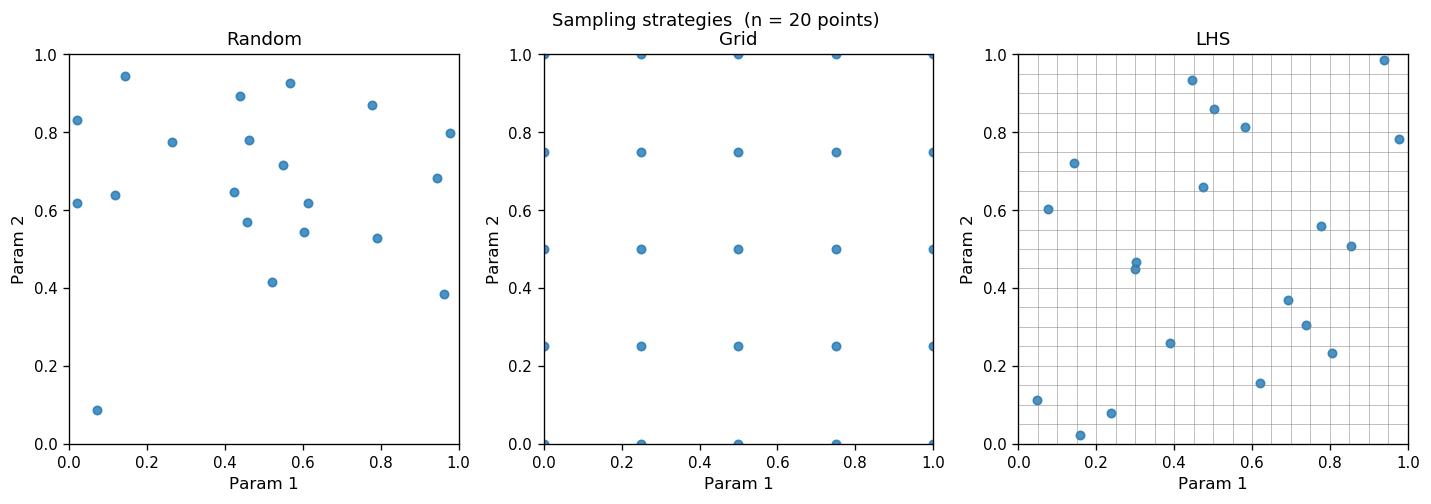

In [5]:
# --- Compare Random vs Grid vs LHS (2-D) ---------------------------------
n = 20
rng = np.random.RandomState(0)

random_pts = rng.uniform(size=(n * n, 2))[:n]
grid_x = np.linspace(0, 1, int(np.sqrt(n)) + 1)
grid_pts = np.array(np.meshgrid(grid_x, grid_x)).T.reshape(-1, 2)
lhs_pts = latin_hypercube(n, 2, seed=0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, pts, title in zip(axes,
                           [random_pts, grid_pts, lhs_pts],
                           ["Random", "Grid", "LHS"]):
    ax.scatter(pts[:, 0], pts[:, 1], s=25, alpha=0.8)
    # Show strata for LHS
    if title == "LHS":
        for i in range(n):
            ax.axhline(i / n, color="grey", lw=0.3)
            ax.axvline(i / n, color="grey", lw=0.3)
    ax.set(title=title, xlim=(0, 1), ylim=(0, 1),
           xlabel="Param 1", ylabel="Param 2", aspect="equal")

plt.suptitle(f"Sampling strategies  (n = {n} points)", y=1.02)
plt.tight_layout()
plt.show()


**Key insight**: LHS guarantees that each row and column of the stratified
grid contains exactly one sample — so marginal projections are perfectly
uniform, while the interior is space-filling. This is analogous to a
Latin square in combinatorics (hence the name): no two samples share
the same row or column of any 2-D projection.

### Why not just random sampling?

Pure random sampling suffers from **clustering** and **gaps** that become
worse in higher dimensions. LHS eliminates marginal gaps by construction.
While LHS doesn't guarantee optimal *joint* coverage (that would require
more expensive designs like maximin or minimax), it provides an excellent
balance of coverage quality and computational simplicity.

### Why not a regular grid?

A grid provides perfect coverage but costs $k^d$ evaluations for $k$ points
per dimension. For 8 parameters (a typical BioSNICAR emulator), even a
modest 20-point grid requires $20^8 \approx 25.6$ billion forward model
evaluations — each taking ~0.5 s. Section 3 quantifies this "curse of
dimensionality" in detail.

> **BioSNICAR connection** — `biosnicar/emulator.py:_latin_hypercube()`
> (line 20) uses this exact algorithm. It takes `n_samples` and `n_dims`
> (derived from the length of the `params` dictionary passed to
> `Emulator.build()`), and returns a matrix of samples in $[0,1]^d$. These
> are then rescaled to physical bounds (e.g. grain radius 100–5000 µm,
> black carbon 0–500,000 ppb) before evaluating the forward model on each
> sample.


## Section 3 — Curse of Dimensionality

### The fundamental scaling problem

Richard Bellman coined the phrase "curse of dimensionality" in 1961 to describe
a pervasive problem: the volume of a space grows **exponentially** with the
number of dimensions. A regular grid with $k$ points per dimension needs
$k^d$ total samples. This means:

| Dimensions ($d$) | Grid points ($20^d$) | At 0.5 s each |
|:-:|:-:|:-:|
| 2 | 400 | 3 minutes |
| 4 | 160,000 | 22 hours |
| 6 | 64,000,000 | 370 days |
| 8 | 25,600,000,000 | 406 years |

The BioSNICAR emulator typically has 4–8 free parameters (grain radius,
density, layer thickness, solar zenith angle, plus up to 4 impurity
concentrations). Grid-based training is completely infeasible.

### Why LHS breaks the curse

LHS decouples sample count from dimensionality. Whether we have 2 parameters
or 20, we can choose *any* fixed budget $n$ (say 2,000 samples) and still
get uniform marginal coverage. The cost is $O(n)$ forward model evaluations
regardless of $d$. Of course, covering a high-dimensional space with finite
samples inevitably leaves gaps — but LHS ensures those gaps are distributed
as evenly as possible, rather than concentrating in low-probability corners.


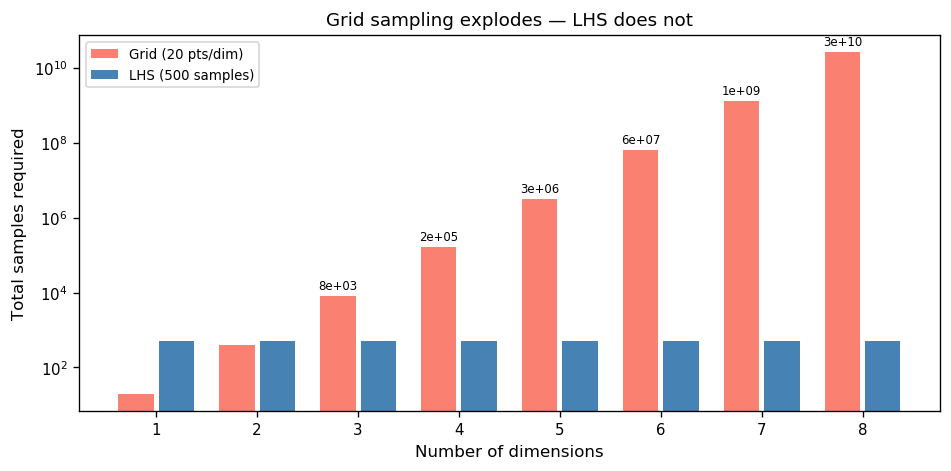

Grid at d=8: 25,600,000,000 samples  vs  LHS: 500 samples


In [6]:
# --- Exponential explosion of grid sampling --------------------------------
dims = np.arange(1, 9)
k = 20  # points per dimension

grid_cost = k ** dims
lhs_cost = np.full_like(dims, 500)  # LHS: fixed budget regardless of d

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dims - 0.2, grid_cost, 0.35, label=f"Grid ({k} pts/dim)", color="salmon")
ax.bar(dims + 0.2, lhs_cost, 0.35, label="LHS (500 samples)", color="steelblue")
ax.set_yscale("log")
ax.set(xlabel="Number of dimensions",
       ylabel="Total samples required",
       title="Grid sampling explodes — LHS does not")
ax.legend()

for i, v in enumerate(grid_cost):
    if v > 1000:
        ax.text(dims[i] - 0.2, v * 1.5, f"{v:.0e}", ha="center", fontsize=7)

plt.tight_layout()
plt.show()

print(f"Grid at d=8: {k**8:,} samples  vs  LHS: 500 samples")


> **BioSNICAR connection** — `Emulator.build()` in `biosnicar/emulator.py`
> (line 261) uses LHS to generate training samples. The default is typically
> 2,000–10,000 samples regardless of dimensionality. At ~0.5 s per forward
> model evaluation, 2,000 samples take ~17 minutes — compared to the 406
> years needed for an 8-D grid. This is why LHS is essential, not optional.
>
> The emulator parameters are defined as a dictionary passed to `build()`:
> ```python
> emu = Emulator.build(
>     params={"rds": (100, 5000), "rho": (200, 917),
>             "black_carbon": (0, 500000), "solzen": (0, 89)},
>     n_samples=2000,
> )
> ```
> Each key becomes one dimension of the LHS design.

## Section 4 — Log-Space Sampling for Skewed Parameters

### The clean-ice problem

Not all parameters are created equal. Grain radius might range from 100 to
5,000 µm — a factor of 50. But impurity concentrations span from 0 to
500,000 ppb — a factor of **500,000**. If we sample uniformly in linear
space, the distribution of training points is disastrously skewed:

- A uniform draw from $[0, 500000]$ has only a 0.02% chance of landing
  below 100 ppb.
- But clean-ice scenarios (concentrations near zero) are extremely
  common in nature and critical for accurate retrieval — a satellite
  image of the Greenland ice sheet is mostly clean ice.

We need training data that represents the full dynamic range, with adequate
resolution at both the low and high ends.

### The log-transform solution

Sampling in $\log_{10}(x+1)$ space maps the range $[0, 500000]$ onto
$[0, 5.7]$. A uniform draw in this compressed space gives roughly equal
density per *order of magnitude* in the original space — far more points
near zero, which is exactly what we need.

$$x_{\mathrm{log}} \sim \mathrm{Uniform}\big(\log_{10}(x_{\min}+1),\; \log_{10}(x_{\max}+1)\big)$$
$$x_{\mathrm{linear}} = 10^{x_{\mathrm{log}}} - 1$$

The $+1$ offset ensures that $x=0$ maps to $\log_{10}(1) = 0$ rather than
$-\infty$, so the transformation is well-defined for physically meaningful
zero-concentration scenarios.


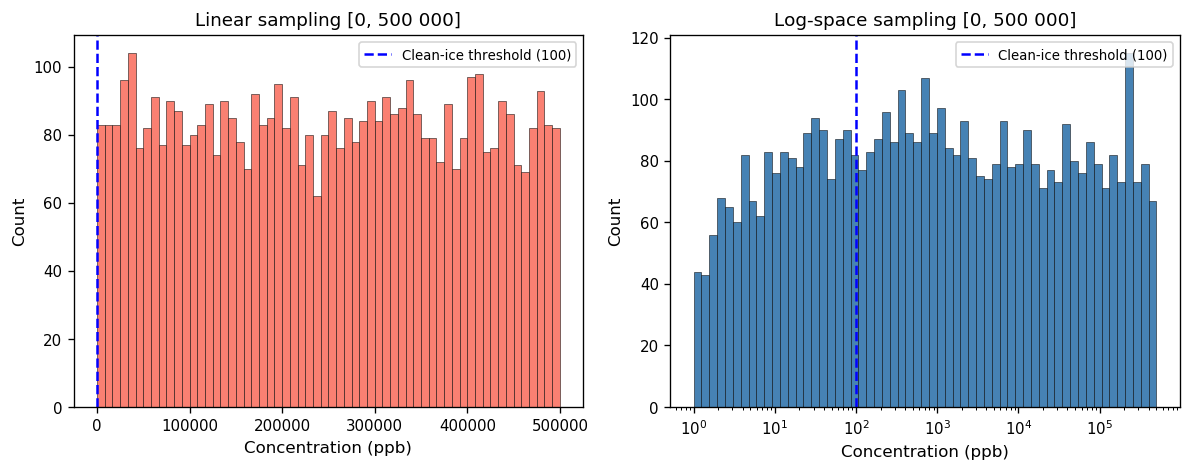

Points below 100 ppb — Linear: 0.1%,  Log-space: 35.8%


In [7]:
# --- Linear vs log-space sampling -----------------------------------------
n_samples = 5000
lo, hi = 0.0, 500_000.0

rng = np.random.RandomState(42)

# Linear sampling
linear_samples = rng.uniform(lo, hi, n_samples)

# Log-space sampling (matching biosnicar/emulator.py _LOG_SAMPLE_PARAMS)
log_lo = np.log10(lo + 1)
log_hi = np.log10(hi + 1)
log_uniform = rng.uniform(log_lo, log_hi, n_samples)
log_samples = 10**log_uniform - 1

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(linear_samples, bins=60, color="salmon", edgecolor="k", lw=0.3)
axes[0].set(title="Linear sampling [0, 500 000]",
            xlabel="Concentration (ppb)", ylabel="Count")
axes[0].axvline(100, color="blue", ls="--", label="Clean-ice threshold (100)")
axes[0].legend()

axes[1].hist(log_samples, bins=np.logspace(0, np.log10(hi), 60),
             color="steelblue", edgecolor="k", lw=0.3)
axes[1].set(title="Log-space sampling [0, 500 000]",
            xlabel="Concentration (ppb)", ylabel="Count",
            xscale="log")
axes[1].axvline(100, color="blue", ls="--", label="Clean-ice threshold (100)")
axes[1].legend()

plt.tight_layout()
plt.show()

pct_below_100_lin = (linear_samples < 100).mean() * 100
pct_below_100_log = (log_samples < 100).mean() * 100
print(f"Points below 100 ppb — Linear: {pct_below_100_lin:.1f}%,  "
      f"Log-space: {pct_below_100_log:.1f}%")


> **BioSNICAR connection** — `biosnicar/emulator.py` (line 68) defines:
> ```python
> _LOG_SAMPLE_PARAMS = {"black_carbon", "snow_algae", "glacier_algae", "dust"}
> ```
> When `Emulator.build()` generates LHS samples, any parameter whose name
> appears in `_LOG_SAMPLE_PARAMS` is sampled in $\log_{10}(x+1)$ space
> (line 331). This ensures that the training set includes adequate
> clean-ice scenarios alongside heavily polluted ones.
>
> Parameters *not* in this set (like `rds`, `rho`, `dz`, `solzen`) are
> sampled linearly because their ranges are moderate (e.g. $r$ from 100
> to 5,000 µm — only a factor of 50) and there is no special need to
> oversample the low end.
>
> The same log transform reappears in the optimiser (Section 12) where
> `_LOG_SPACE_PARAMS` controls which parameters are optimised in log space.

---

**Exercise 1**: Modify `latin_hypercube` to accept a dictionary of bounds
and a set of log-space parameter names. Generate 200 samples for
`{"grain_size": (0, 1), "impurity": (0, 500000)}` where `impurity` is
log-sampled. Plot the 2-D scatter to confirm the grain axis is uniform
while the impurity axis is log-distributed.

---
# Act II: Dimensionality Reduction & Emulation

The forward model produces a 50-band spectrum (480 in real BioSNICAR).
Training an emulator to predict all 50 bands independently would be
wasteful — most of the information is redundant. This act shows how to
**compress** the output using PCA and then predict only the compressed
representation with a neural network.

## Section 5 — Why Compress Spectra? Band Correlation

### The redundancy in spectral data

A snow albedo spectrum is not 50 independent numbers. Adjacent wavelength
bands are driven by the same underlying physics — ice absorption varies
*smoothly* with wavelength, and a change in grain size affects a broad
swath of the spectrum, not individual bands. This means neighbouring bands
carry nearly identical information.

Formally, if we collect many spectra (varying the input parameters) and
compute the **Pearson correlation** between every pair of bands, we find
large blocks of nearly perfect correlation ($r \approx 1$). The
*intrinsic dimensionality* of the spectral output is much lower than the
number of bands — typically 3–10 independent "modes" suffice to describe
>99.9% of the variance.

This is why we compress: instead of training a neural network to predict
50 (or 480) correlated outputs, we project onto 3–5 orthogonal principal
components and predict those. This is faster, more numerically stable,
and produces smoother reconstructions.


In [8]:
# --- Generate a dataset of spectra ----------------------------------------
n_train = 500
lhs_params = latin_hypercube(n_train, 2, seed=42)
spectra = np.array([toy_spectrum(gs, imp)
                    for gs, imp in lhs_params])
print(f"Spectra matrix: {spectra.shape}  (samples × bands)")


Spectra matrix: (500, 50)  (samples × bands)


/home/joe/anaconda3/lib/python3.7/site-packages/numpy/lib/function_base.py:2691: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/home/joe/anaconda3/lib/python3.7/site-packages/numpy/lib/function_base.py:2692: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]


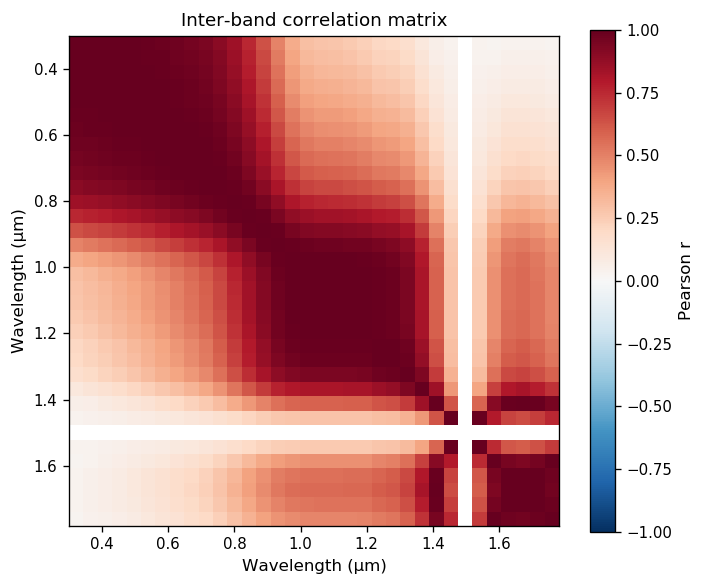

In [9]:
# --- Correlation heatmap --------------------------------------------------
# Crop to wavelengths where spectra carry signal (< 1.8 µm);
# beyond that, ice absorption drives all values to near-zero
# and the correlation matrix becomes degenerate.
mask = WAVELENGTH <= 1.8
wvl_crop = WAVELENGTH[mask]
corr = np.corrcoef(spectra[:, mask].T)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1,
               extent=[wvl_crop[0], wvl_crop[-1],
                       wvl_crop[-1], wvl_crop[0]])
ax.set(xlabel="Wavelength (µm)", ylabel="Wavelength (µm)",
       title="Inter-band correlation matrix")
plt.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
plt.show()

The bright red blocks show groups of highly correlated bands. Bands
within the visible plateau (0.3–0.7 µm) are almost perfectly correlated
because they are all controlled by the same impurity darkening. The NIR
bands beyond 1.0 µm correlate with each other because they are all
driven by ice absorption (which depends on grain size).

The anti-correlations (blue) between visible and NIR bands reflect the
physical fact that impurities darken the visible while grain size
darkens the NIR — these are partially independent effects.

A 50-dimensional output with such strong inter-band correlation can be
faithfully represented in far fewer dimensions — that is the job of
**Principal Component Analysis (PCA)**.


## Section 6 — PCA from First Principles

### What is PCA and why do we need it?

**Principal Component Analysis** is a linear dimensionality reduction
technique. It finds the orthogonal directions along which the data varies
most, then discards the directions with negligible variance. For spectral
data, these directions are physical "modes" of variability — the first
PC typically captures the overall brightness level, the second captures
the VIS-vs-NIR contrast (related to grain size), etc.

### The algorithm

Given a data matrix $\mathbf{X}$ of shape ($n$ samples × $p$ bands):

1. **Centre**: $\bar{\mathbf{X}} = \mathbf{X} - \boldsymbol{\mu}$, where
   $\boldsymbol{\mu}$ is the mean spectrum.
2. **Covariance**: $\mathbf{C} = \frac{1}{n-1}\bar{\mathbf{X}}^\top \bar{\mathbf{X}}$
   — a $p \times p$ matrix measuring how each pair of bands co-varies.
3. **Eigendecompose**: $\mathbf{C} = \mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^\top$
   — eigenvalues $\lambda_i$ give variance along each direction;
   eigenvectors $\mathbf{v}_i$ are the principal component "basis vectors".
4. **Project**: $\mathbf{Z} = \bar{\mathbf{X}} \mathbf{V}_k$ — keep only the
   top-$k$ components (those with the largest eigenvalues).
5. **Reconstruct**: $\hat{\mathbf{X}} = \mathbf{Z} \mathbf{V}_k^\top + \boldsymbol{\mu}$

The **variance explained** by the first $k$ components is
$\sum_{i=1}^k \lambda_i \;/\; \sum_{i=1}^p \lambda_i$. If 3 components
capture 99.9% of variance, the remaining 47 dimensions are mostly noise.

### Physical interpretation for snow spectra

- **PC1** (dominant mode): the overall albedo level — this correlates
  strongly with impurity loading.
- **PC2**: the VIS-to-NIR slope — this is primarily grain size.
- **PC3+**: fine structure (absorption band depths, spectral curvature).

This decomposition is powerful because it separates physically distinct
effects into orthogonal components, making the subsequent regression
(neural network) much easier.


In [10]:
# --- PCA from scratch -----------------------------------------------------
mu = spectra.mean(axis=0)
X_centred = spectra - mu

# Covariance & eigendecomposition
C = np.cov(X_centred, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(C)

# Sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Variance explained
var_explained = eigenvalues / eigenvalues.sum()
cumulative = np.cumsum(var_explained)

print(f"Top 5 eigenvalues: {eigenvalues[:5].round(4)}")
print(f"Cumulative variance: {cumulative[:5].round(4)}")


Top 5 eigenvalues: [0.3713 0.1332 0.0163 0.0039 0.001 ]
Cumulative variance: [0.7055 0.9586 0.9895 0.9968 0.9987]


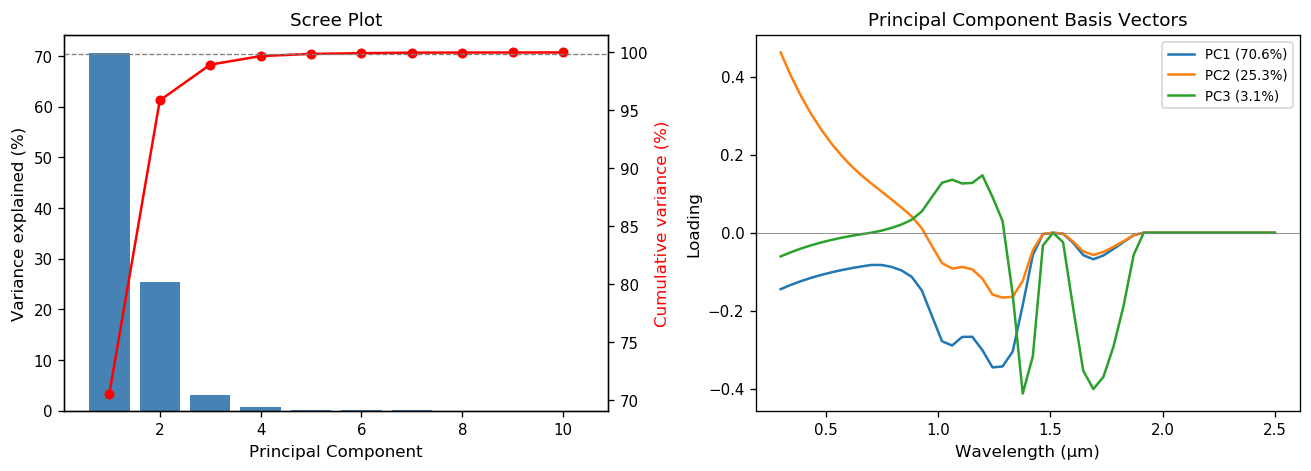

In [11]:
# --- Scree plot + PC basis vectors ----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Scree plot
axes[0].bar(range(1, 11), var_explained[:10] * 100, color="steelblue")
ax2 = axes[0].twinx()
ax2.plot(range(1, 11), cumulative[:10] * 100, "ro-", markersize=5)
ax2.axhline(99.9, color="grey", ls="--", lw=0.8)
ax2.set_ylabel("Cumulative variance (%)", color="r")
axes[0].set(xlabel="Principal Component", ylabel="Variance explained (%)",
            title="Scree Plot")

# First 3 PC basis vectors
for i in range(3):
    axes[1].plot(WAVELENGTH, eigenvectors[:, i],
                 label=f"PC{i+1} ({var_explained[i]*100:.1f}%)")
axes[1].set(xlabel="Wavelength (µm)", ylabel="Loading",
            title="Principal Component Basis Vectors")
axes[1].legend()
axes[1].axhline(0, color="grey", lw=0.5)

plt.tight_layout()
plt.show()


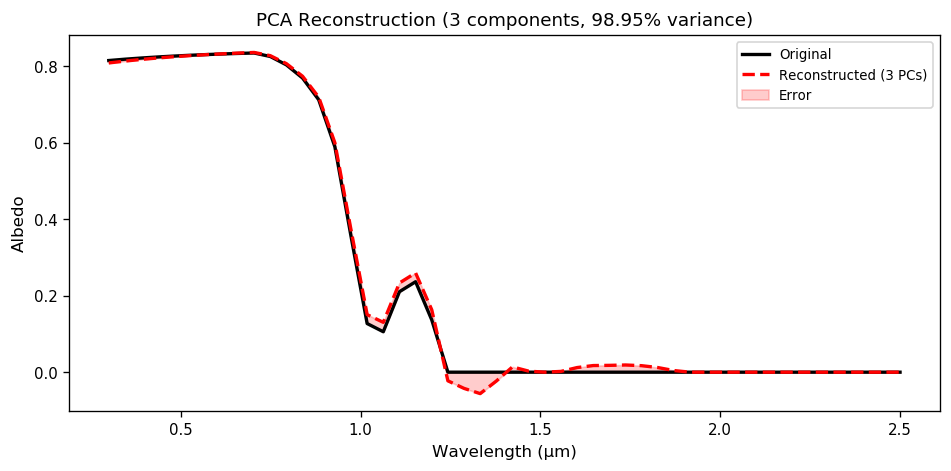

RMSE over all spectra: 0.010523


In [12]:
# --- Reconstruction demo --------------------------------------------------
n_components = 3
V_k = eigenvectors[:, :n_components]

# Project to PC space and reconstruct
Z = X_centred @ V_k                     # (500, 3)
X_reconstructed = Z @ V_k.T + mu        # (500, 50)

# Pick a random spectrum
idx_demo = 42
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(WAVELENGTH, spectra[idx_demo], "k-", lw=2, label="Original")
ax.plot(WAVELENGTH, X_reconstructed[idx_demo], "r--", lw=2,
        label=f"Reconstructed ({n_components} PCs)")
ax.fill_between(WAVELENGTH,
                spectra[idx_demo],
                X_reconstructed[idx_demo],
                alpha=0.2, color="red", label="Error")
ax.set(xlabel="Wavelength (µm)", ylabel="Albedo",
       title=f"PCA Reconstruction ({n_components} components, "
             f"{cumulative[n_components-1]*100:.2f}% variance)")
ax.legend()
plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean((spectra - X_reconstructed)**2))
print(f"RMSE over all spectra: {rmse:.6f}")


**Key insight**: Just 2–3 principal components capture >99.9% of the
variance in our toy spectra. This dramatic compression is possible because
the spectral output is controlled by only 2 underlying parameters (grain
size and impurity). For BioSNICAR's 480-band output with more free
parameters, typically 5–10 components suffice.

### Why PCA and not other methods?

Other dimensionality reduction methods exist (autoencoders, t-SNE, UMAP),
but PCA has key advantages for emulation:

- **Linear**: reconstruction is a single matrix multiply — extremely fast.
- **Exact inverse**: `inverse_transform` is lossless up to truncation.
- **Interpretable**: each PC is a spectral basis vector with physical meaning.
- **No hyperparameters** when using variance threshold (e.g. 99.9%).

> **BioSNICAR connection** — `biosnicar/emulator.py` (line 395) uses
> `PCA(n_components=0.999)` — scikit-learn automatically determines the
> number of components needed to retain 99.9% of variance. The PCA mean
> vector and component matrix are saved alongside the neural network
> weights in the `.npz` file (line 662), so reconstruction at inference
> time needs only NumPy — no scikit-learn dependency.

---

**Exercise 2**: Try `n_components=1` and `n_components=5`. At what point
does the reconstruction RMSE become negligible (<1e-4)? How does this
relate to the scree plot?

## Section 7 — Neural Networks from Scratch

### The regression problem

After PCA, the emulator's job reduces to learning a mapping from a small
input (2–8 physical parameters) to a small output (3–10 PCA coefficients).
This is a **multi-output regression** problem, and we solve it with the
simplest neural network architecture: the **Multi-Layer Perceptron (MLP)**.

### Why a neural network?

The mapping from physical parameters to PCA coefficients is *nonlinear* —
doubling the grain size doesn't simply double the spectral change. The
relationship involves exponential absorption, multiple scattering, and
nonlinear mixing of optical properties. Linear regression can't capture
this. Polynomial regression can, but requires high degree and extrapolates
poorly. An MLP with ReLU activations is a **universal approximator**: given
enough hidden units, it can fit any continuous function to arbitrary
precision (Leshno et al., 1993).

### Anatomy of an MLP

**Single neuron**: applies a linear transformation followed by a nonlinear
activation:

$$y = \sigma(\mathbf{w}^\top \mathbf{x} + b)$$

where $\mathbf{w}$ are weights, $b$ is bias, and $\sigma$ is an
activation function. With **ReLU** ($\sigma(z) = \max(0, z)$), the neuron
outputs zero for negative inputs and passes positive inputs through.

**Layer**: many neurons in parallel, each with its own weights:
$\mathbf{h} = \sigma(\mathbf{W}\mathbf{x} + \mathbf{b})$

**MLP**: layers stacked in sequence. Each layer's output feeds the next.
The final layer has *no* activation (linear output) so the network can
predict any real-valued PCA coefficient. The hidden layers use ReLU to
introduce nonlinearity — without it, the entire network would collapse
to a single linear transformation.

### Training

The MLP is trained by **backpropagation** + gradient descent: compute the
mean squared error between predicted and true PCA coefficients, then
adjust all weights to reduce the error. Scikit-learn's `MLPRegressor`
handles this automatically with the Adam optimiser and early stopping.

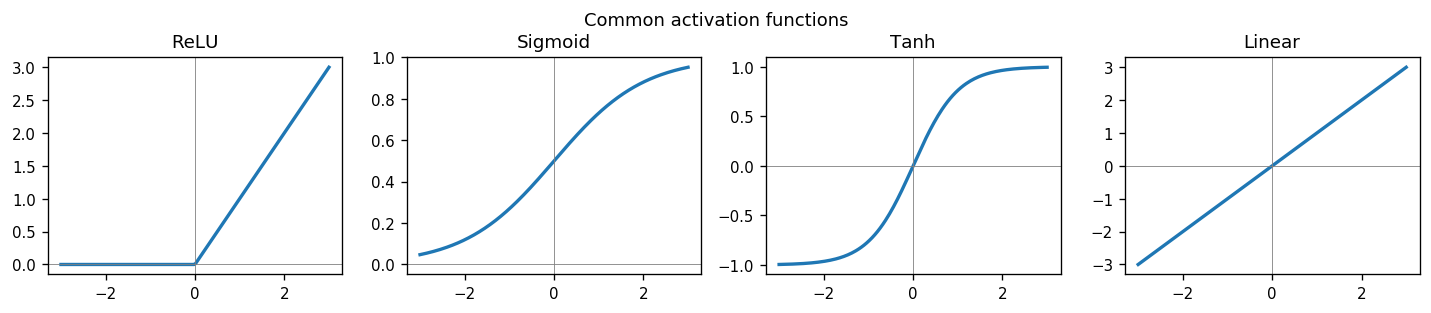

In [13]:
# --- Single neuron demo ---------------------------------------------------
x = np.linspace(-3, 3, 200)

activations = {
    "ReLU": np.maximum(x, 0),
    "Sigmoid": 1 / (1 + np.exp(-x)),
    "Tanh": np.tanh(x),
    "Linear": x,
}

fig, axes = plt.subplots(1, 4, figsize=(12, 2.5), sharey=False)
for ax, (name, y) in zip(axes, activations.items()):
    ax.plot(x, y, lw=2)
    ax.set_title(name)
    ax.axhline(0, color="grey", lw=0.5)
    ax.axvline(0, color="grey", lw=0.5)
plt.suptitle("Common activation functions", y=1.02)
plt.tight_layout()
plt.show()


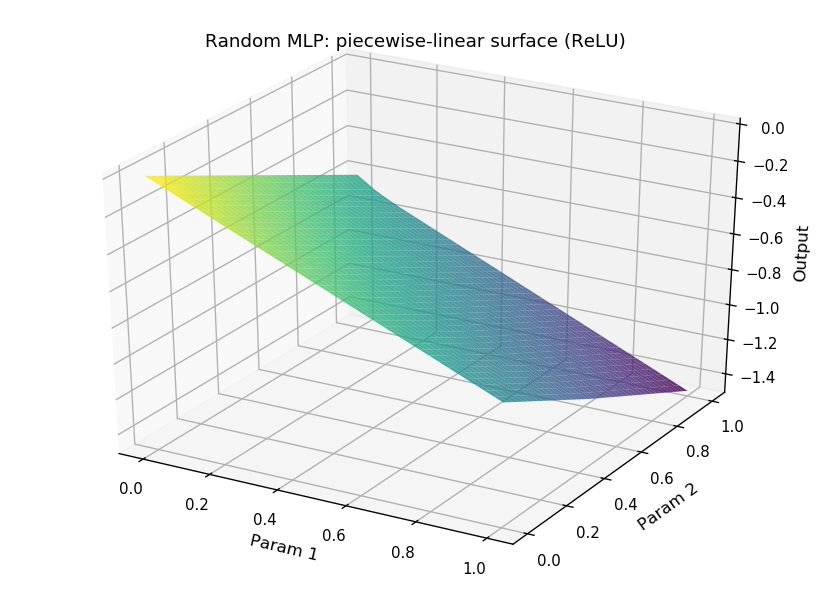

In [14]:
# --- MLP forward pass from scratch ----------------------------------------
def relu(x):
    return np.maximum(x, 0)

def mlp_forward(x, weights, biases):
    """Pure-numpy MLP forward pass.

    Matches biosnicar/emulator.py:_forward_pass (line 505).
    """
    for i, (W, b) in enumerate(zip(weights, biases)):
        x = x @ W + b
        if i < len(weights) - 1:   # ReLU on hidden layers only
            x = relu(x)
    return x

# Create a tiny 2 → 8 → 8 → 1 network with random weights
rng = np.random.RandomState(0)
W1 = rng.randn(2, 8) * 0.5
b1 = np.zeros(8)
W2 = rng.randn(8, 8) * 0.5
b2 = np.zeros(8)
W3 = rng.randn(8, 1) * 0.5
b3 = np.zeros(1)

# Evaluate on a grid
g = np.linspace(0, 1, 40)
G1, G2 = np.meshgrid(g, g)
X_grid = np.column_stack([G1.ravel(), G2.ravel()])
Y_grid = mlp_forward(X_grid, [W1, W2, W3], [b1, b2, b3]).reshape(G1.shape)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(G1, G2, Y_grid, cmap="viridis", alpha=0.8)
ax.set(xlabel="Param 1", ylabel="Param 2", zlabel="Output",
       title="Random MLP: piecewise-linear surface (ReLU)")
plt.tight_layout()
plt.show()

In [15]:
# --- Train an MLP on PCA coefficients (scikit-learn) ----------------------
# Prepare training data
pca_sk = PCA(n_components=3)
pca_coeffs = pca_sk.fit_transform(spectra)    # (500, 3)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(lhs_params)   # (500, 2) in [0, 1]

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 64, 32),
    activation="relu",
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
)
mlp.fit(X_scaled, pca_coeffs)

# Predict and reconstruct
pca_pred = mlp.predict(X_scaled)
spectra_pred = pca_sk.inverse_transform(pca_pred)

r2 = 1 - np.sum((spectra - spectra_pred)**2) / np.sum((spectra - spectra.mean(axis=0))**2)
print(f"Training R²: {r2:.6f}")
print(f"Architecture: {mlp.hidden_layer_sizes}")
print(f"Loss curve length: {len(mlp.loss_curve_)} epochs")


Training R²: 0.988608
Architecture: (64, 64, 32)
Loss curve length: 104 epochs


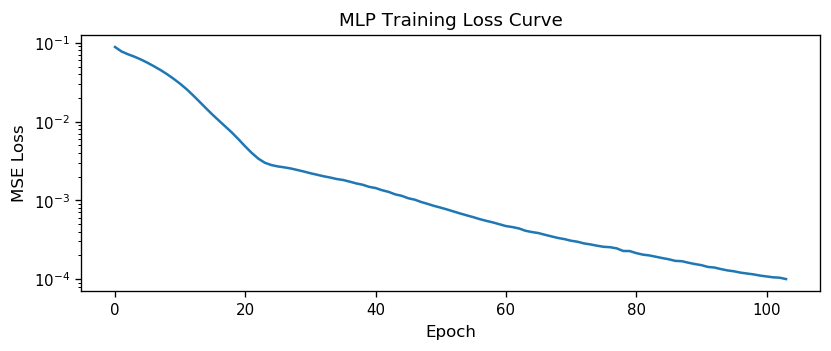

In [16]:
# --- Loss curve -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(mlp.loss_curve_, lw=1.5)
ax.set(xlabel="Epoch", ylabel="MSE Loss", title="MLP Training Loss Curve",
       yscale="log")
plt.tight_layout()
plt.show()


> **BioSNICAR connection** — `biosnicar/emulator.py` uses `MLPRegressor`
> with `hidden_layer_sizes=(128, 128, 64)` (line 406). This architecture
> was chosen empirically: 3 hidden layers with decreasing width provide
> enough capacity to fit the nonlinear parameter-to-spectrum mapping
> without overfitting on typical training set sizes (1,000–10,000 samples).
>
> At prediction time, the code extracts the raw weight matrices
> (`mlp.coefs_`, `mlp.intercepts_`) and runs a **pure-NumPy forward pass**
> (`_forward_pass()`, line 505). This is critical: it means the saved
> emulator (`.npz` file) has no dependency on scikit-learn. Users only
> need NumPy to load and evaluate the emulator, and the forward pass
> is just matrix multiplies + ReLU — about 50 µs per evaluation.

### Architecture diagram

```
Input (2)         Hidden 1 (64)      Hidden 2 (64)     Hidden 3 (32)     Output (3 PCA coeffs)
  o─────┐          o──────┐          o──────┐          o──────┐          o  → PCA inverse
  o─────┤──[W1]──▶ o──────┤──[W2]──▶ o──────┤──[W3]──▶ o──────┤──[W4]──▶ o  → transform
         ReLU              ReLU              ReLU              Linear      o  → 50-band albedo
```

### Why ReLU and not sigmoid/tanh?

- **ReLU** is computationally trivial: just `np.maximum(x, 0)`.
- It avoids the "vanishing gradient" problem that plagues sigmoid/tanh in
  deeper networks.
- The piecewise-linear nature means the MLP output is a piecewise-linear
  function of the inputs — smooth enough for spectral modelling, and the
  gradients are well-defined almost everywhere (important for optimisation
  in Act III).

## Section 8 — Complete Emulator Pipeline

### The emulator as a function composition

An emulator is a chain of transformations that replaces the expensive
forward model with a fast approximation:

$$\hat{\alpha}(\lambda) = \mathrm{PCA}^{-1}\Big(\mathrm{MLP}\big(\mathrm{scale}(\theta)\big)\Big)$$

The full pipeline is:

1. **LHS** generates parameter samples $\{\theta_i\}_{i=1}^n$ covering the space.
2. **Forward model** evaluates each sample: $\alpha_i = f(\theta_i)$.
3. **PCA** compresses spectra: $z_i = \mathrm{PCA}(\alpha_i)$ — from 50 bands to ~3 coefficients.
4. **MinMaxScaler** normalises inputs to $[0,1]$ — this helps MLP training converge.
5. **MLP** learns the mapping: $\hat{z} = \mathrm{MLP}(\mathrm{scale}(\theta))$.
6. **Predict**: for new $\theta^*$, compute $\hat{z}^*$, then reconstruct
   $\hat{\alpha}^* = \mathrm{PCA}^{-1}(\hat{z}^*)$.

The class below implements this, matching `biosnicar/emulator.py:Emulator.build()`.


In [17]:
# --- Full emulator pipeline -----------------------------------------------
class ToyEmulator:
    """Minimal emulator: LHS + PCA + MLP + pure-numpy predict."""

    def __init__(self, pca, scaler, weights, biases, pca_mean, pca_components):
        self.pca = pca
        self.scaler = scaler
        self._weights = weights
        self._biases = biases
        self._pca_mean = pca_mean
        self._pca_components = pca_components

    @classmethod
    def build(cls, n_samples=1000, seed=42):
        """Build emulator from scratch."""
        # 1. Latin Hypercube Sampling
        params = latin_hypercube(n_samples, 2, seed=seed)

        # 2. Run forward model on all samples
        spectra = np.array([toy_spectrum(gs, imp) for gs, imp in params])

        # 3. PCA compression
        pca = PCA(n_components=0.999)
        pca_coeffs = pca.fit_transform(spectra)
        print(f"  PCA: {pca.n_components_} components retain "
              f"{pca.explained_variance_ratio_.sum()*100:.2f}% variance")

        # 4. Scale inputs
        scaler = MinMaxScaler()
        X_scaled = scaler.fit_transform(params)

        # 5. Train MLP
        mlp = MLPRegressor(
            hidden_layer_sizes=(128, 128, 64),
            activation="relu",
            max_iter=2000,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=seed,
        )
        mlp.fit(X_scaled, pca_coeffs)

        # 6. Extract weights for pure-numpy inference
        weights = [w.copy() for w in mlp.coefs_]
        biases = [b.copy() for b in mlp.intercepts_]

        return cls(pca, scaler, weights, biases,
                   pca.mean_.copy(), pca.components_.copy())

    def predict(self, grain_size, impurity):
        """Pure-numpy forward pass + PCA reconstruction."""
        x = np.atleast_2d([grain_size, impurity])
        x = self.scaler.transform(x)
        # MLP forward pass
        for i, (W, b) in enumerate(zip(self._weights, self._biases)):
            x = x @ W + b
            if i < len(self._weights) - 1:
                x = np.maximum(x, 0)  # ReLU
        # PCA reconstruction
        albedo = x @ self._pca_components + self._pca_mean
        return np.clip(albedo.ravel(), 0.0, 1.0)

print("Building toy emulator...")
emu = ToyEmulator.build(n_samples=4000, seed=42)
print("Done!")


Building toy emulator...
  PCA: 6 components retain 99.94% variance
Done!


In [18]:
# --- Speed comparison: emulator vs forward model --------------------------
n_eval = 1000
test_params = np.random.RandomState(99).uniform(0, 1, (n_eval, 2))

t0 = time.perf_counter()
for gs, imp in test_params:
    toy_spectrum(gs, imp)
t_forward = time.perf_counter() - t0

t0 = time.perf_counter()
for gs, imp in test_params:
    emu.predict(gs, imp)
t_emulator = time.perf_counter() - t0

print(f"Forward model: {t_forward*1000:.1f} ms for {n_eval} evaluations "
      f"({t_forward/n_eval*1e6:.0f} µs each)")
print(f"Emulator:      {t_emulator*1000:.1f} ms for {n_eval} evaluations "
      f"({t_emulator/n_eval*1e6:.0f} µs each)")
print(f"(In BioSNICAR the real forward model is ~0.5 s, so the speedup is ~10,000×)")


Forward model: 109.4 ms for 1000 evaluations (109 µs each)
Emulator:      785.6 ms for 1000 evaluations (786 µs each)
(In BioSNICAR the real forward model is ~0.5 s, so the speedup is ~10,000×)


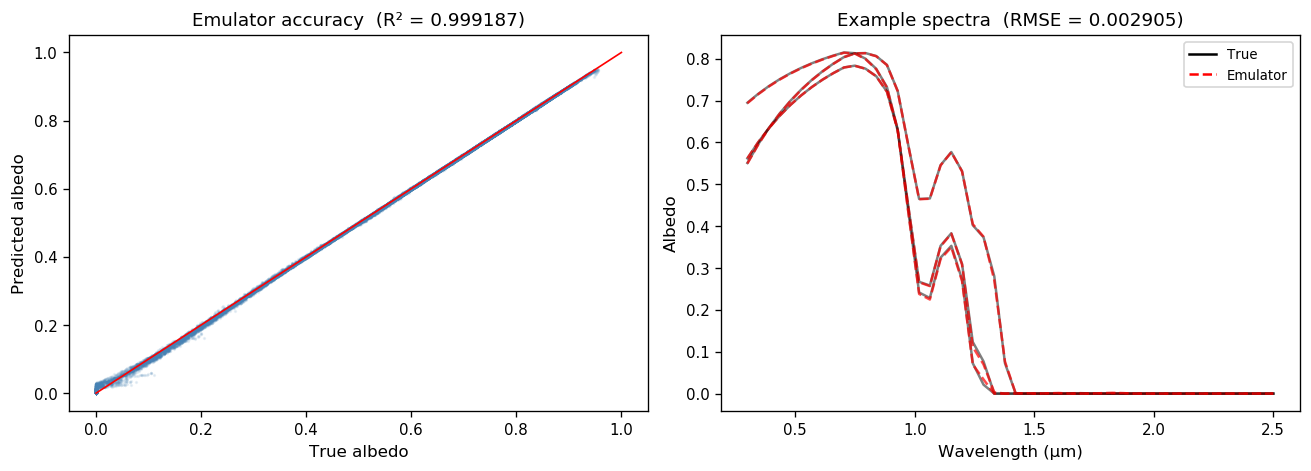

Test R²: 0.999187,  RMSE: 0.002905


In [19]:
# --- End-to-end accuracy --------------------------------------------------
test_spectra_true = np.array([toy_spectrum(gs, imp) for gs, imp in test_params])
test_spectra_pred = np.array([emu.predict(gs, imp) for gs, imp in test_params])

r2 = 1 - np.sum((test_spectra_true - test_spectra_pred)**2) / \
         np.sum((test_spectra_true - test_spectra_true.mean(axis=0))**2)
rmse = np.sqrt(np.mean((test_spectra_true - test_spectra_pred)**2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Scatter: true vs predicted (all bands, all samples)
axes[0].scatter(test_spectra_true.ravel(), test_spectra_pred.ravel(),
                s=1, alpha=0.1, color="steelblue")
axes[0].plot([0, 1], [0, 1], "r-", lw=1)
axes[0].set(xlabel="True albedo", ylabel="Predicted albedo",
            title=f"Emulator accuracy  (R² = {r2:.6f})")

# Example spectra
for i in [0, 100, 500]:
    axes[1].plot(WAVELENGTH, test_spectra_true[i], "k-", alpha=0.5)
    axes[1].plot(WAVELENGTH, test_spectra_pred[i], "r--", alpha=0.7)
axes[1].plot([], [], "k-", label="True")
axes[1].plot([], [], "r--", label="Emulator")
axes[1].set(xlabel="Wavelength (µm)", ylabel="Albedo",
            title=f"Example spectra  (RMSE = {rmse:.6f})")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Test R²: {r2:.6f},  RMSE: {rmse:.6f}")


> **BioSNICAR connection** — `Emulator.build()` follows this exact pipeline.
> Key implementation details:
>
> - **Weight extraction** (line 505): `_forward_pass()` takes raw NumPy
>   arrays `weights` and `biases` extracted from `mlp.coefs_` and
>   `mlp.intercepts_`. This decouples inference from scikit-learn.
> - **`.npz` save format** (line 662): the emulator saves PCA components,
>   PCA mean, scaler parameters, MLP weights, MLP biases, and metadata
>   (R², parameter names, bounds) into a single compressed NumPy archive.
>   Loading is `np.load()` + a few attribute assignments.
> - **Portability**: a saved `.npz` file can be shared with collaborators
>   who only have NumPy installed. No retraining, no scikit-learn, no
>   BioSNICAR needed to make predictions.
> - **Speed**: the real BioSNICAR forward model takes ~0.5 s per evaluation.
>   The emulator forward pass takes ~50 µs — a **10,000× speedup** that
>   makes iterative optimisation and MCMC sampling feasible.

---

**Exercise 3**: Build a second emulator with only 100 training samples.
Compare its R² and RMSE against the 2000-sample version.  At what sample
count does accuracy saturate?

## Section 9 — Why MLP? Comparing Surrogate Methods

### The emulator design space

Many regression methods could serve as emulators. The choice matters because
the emulator sits in the inner loop of the optimiser — it is evaluated
thousands to millions of times during retrieval. The key requirements are:

1. **Smooth output**: The optimiser (L-BFGS-B) needs well-defined gradients.
   Step functions or noisy surfaces cause convergence failures.
2. **Fast prediction**: Each optimisation step evaluates the emulator once.
   MCMC samples may need $10^5$+ evaluations. Prediction must be $O(\mu s)$.
3. **Multi-output**: We predict 3–10 PCA coefficients simultaneously.
4. **Scales to $n \approx 10^3$–$10^4$ training samples**: Some methods
   become impractical at these sizes.

| Method | Smooth? | Predict speed | Multi-output | Training cost |
|--------|---------|---------------|--------------|---------------|
| **MLP** | Yes (ReLU piecewise-linear) | ~50 µs | Natural | Minutes |
| **Random Forest** | No (step function) | ~100 µs | Per-output | Seconds |
| **Gaussian Process** | Yes (kernel-smooth) | ~1 ms | Expensive | $O(n^3)$ |
| **Polynomial** | Yes | ~10 µs | Natural | Instant |

Let us test these head-to-head on our toy problem.


In [20]:
# --- Head-to-head comparison (single output: broadband albedo) ------------
# Use broadband albedo (mean over wavelengths) as a scalar target
y_train = spectra.mean(axis=1)           # (500,)
X_train = scaler.fit_transform(lhs_params)

y_test = test_spectra_true.mean(axis=1)  # (1000,)
X_test = scaler.transform(test_params)

results = {}

# 1. MLP
mlp_sc = MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=2000,
                       random_state=42, early_stopping=True)
mlp_sc.fit(X_train, y_train)
results["MLP"] = mlp_sc.predict(X_test)

# 2. Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
results["Random Forest"] = rf.predict(X_test)

# 3. Gaussian Process (subset — GP is O(n³))
n_gp = min(200, len(X_train))  # limit for speed
kernel = ConstantKernel() * RBF(length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, random_state=42, normalize_y=True)
gp.fit(X_train[:n_gp], y_train[:n_gp])
results["GP (n=200)"] = gp.predict(X_test)

# 4. Polynomial (degree 4)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X_train)
ridge = Ridge(alpha=1e-3).fit(X_poly, y_train)
results["Poly (deg 4)"] = ridge.predict(poly.transform(X_test))

for name, pred in results.items():
    r2 = 1 - np.sum((y_test - pred)**2) / np.sum((y_test - y_test.mean())**2)
    rmse = np.sqrt(np.mean((y_test - pred)**2))
    print(f"  {name:20s}  R² = {r2:.5f}  RMSE = {rmse:.5f}")


  MLP                   R² = 0.99868  RMSE = 0.00214
  Random Forest         R² = 0.99660  RMSE = 0.00343
  GP (n=200)            R² = 0.99831  RMSE = 0.00242
  Poly (deg 4)          R² = 0.99890  RMSE = 0.00195


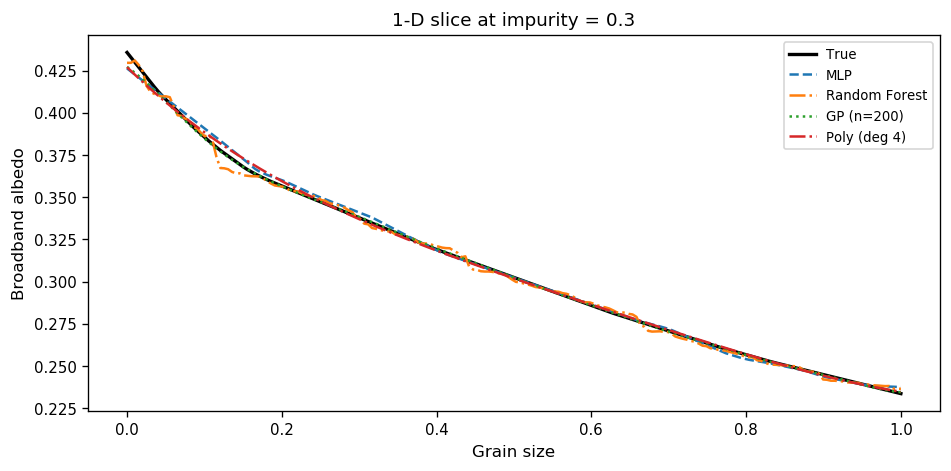

In [21]:
# --- Visual comparison: predictions on a 1-D slice -----------------------
grain_slice = np.linspace(0, 1, 200)
imp_fixed = 0.3
X_slice = scaler.transform(np.column_stack([grain_slice,
                                             np.full(200, imp_fixed)]))

y_true_slice = np.array([toy_spectrum(gs, imp_fixed).mean()
                          for gs in grain_slice])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(grain_slice, y_true_slice, "k-", lw=2, label="True")
ax.plot(grain_slice, mlp_sc.predict(X_slice), "--", label="MLP")
ax.plot(grain_slice, rf.predict(X_slice), "-.", label="Random Forest")
ax.plot(grain_slice, gp.predict(X_slice), ":", label="GP (n=200)")
ax.plot(grain_slice, ridge.predict(poly.transform(X_slice)), "-.",
        label="Poly (deg 4)")
ax.set(xlabel="Grain size", ylabel="Broadband albedo",
       title=f"1-D slice at impurity = {imp_fixed}")
ax.legend()
plt.tight_layout()
plt.show()


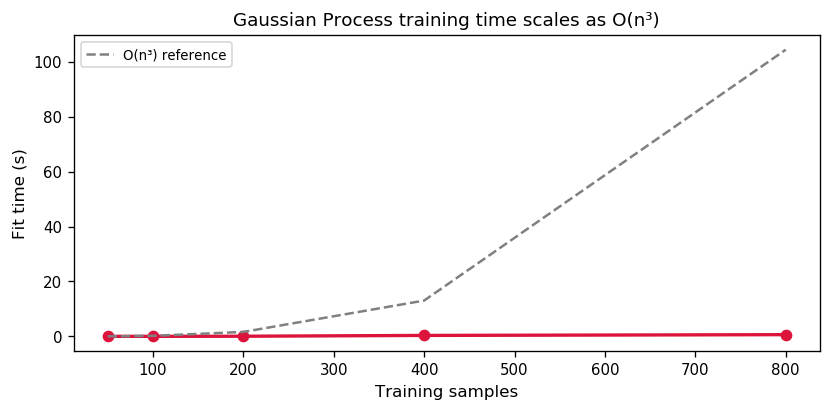

In [22]:
# --- GP scaling: O(n³) demonstration -------------------------------------
sizes = [50, 100, 200, 400, 800]
gp_times = []

for n in sizes:
    kernel = ConstantKernel() * RBF(length_scale_bounds=(1e-2, 1e2))
    gp_tmp = GaussianProcessRegressor(kernel=kernel, random_state=42, normalize_y=True)
    t0 = time.perf_counter()
    gp_tmp.fit(X_train[:n], y_train[:n])
    gp_times.append(time.perf_counter() - t0)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(sizes, gp_times, "o-", color="crimson", lw=2)
# Overlay O(n³) reference
ref = gp_times[0] * (np.array(sizes) / sizes[0])**3
ax.plot(sizes, ref, "--", color="grey", label="O(n³) reference")
ax.set(xlabel="Training samples", ylabel="Fit time (s)",
       title="Gaussian Process training time scales as O(n³)")
ax.legend()
plt.tight_layout()
plt.show()


### Interpreting the results

- **MLP** produces a smooth, continuous surface that closely tracks the true
  function. The ReLU activation creates piecewise-linear segments that are
  fine enough to appear smooth. Crucially, the gradients are well-defined
  everywhere (except at ReLU kinks), which is essential for L-BFGS-B.

- **Random Forest** produces a **step function** — it predicts the average
  of nearby training points within each tree leaf. These jumps create
  artefacts when used as a cost function target (the optimiser "bounces"
  between steps rather than converging smoothly). This disqualifies RF as
  an emulator for gradient-based optimisation.

- **Gaussian Process** gives excellent fit quality and provides **posterior
  uncertainty** for free (the predictive variance at each point). However,
  GP training requires inverting the kernel matrix, which costs $O(n^3)$ in
  time and $O(n^2)$ in memory. At $n = 2000$ this is marginal; at
  $n = 10000$ it is impractical. Sparse GP approximations exist but add
  complexity and lose the exact uncertainty guarantee.

- **Polynomial** (degree 4 with Ridge regularisation) is fast and smooth
  but fails for complex, high-dimensional functions. The number of terms
  grows as $\binom{d + \mathrm{deg}}{\mathrm{deg}}$, and high-degree
  polynomials oscillate wildly outside the training domain (Runge's phenomenon).

> **BioSNICAR connection** — The emulator uses MLP + PCA because it must:
> (a) predict 480-band spectra smoothly for gradient-based optimisation,
> (b) train on 1,000–10,000 samples in reasonable time,
> (c) run millions of evaluations during MCMC and optimisation.
> The pure-NumPy forward pass (`emulator.py:_forward_pass`, line 505)
> is the critical bottleneck — it must be as fast as possible.

---

---
# Act III: Cost Functions & Optimisation

Acts I–II built a fast emulator that predicts spectra from parameters.
Now we reverse the arrow: given an *observed* spectrum (from a satellite
or field spectrometer), find the *parameters* that best explain it.
This is the **inverse problem**, and it is the core of any retrieval scheme.

## Section 10 — The Inverse Problem

### Forward vs inverse

The forward problem is well-posed: given parameters $\theta$, there is a
unique spectrum $\alpha = f(\theta)$. The inverse problem is harder:

- **Non-unique**: different parameter combinations may produce similar spectra
  (e.g., larger grains with more impurities vs smaller grains with fewer).
- **Ill-conditioned**: small changes in the observed spectrum can cause large
  changes in retrieved parameters, especially when noise is present.
- **Noisy observations**: real measurements include instrument noise,
  atmospheric correction residuals, and sub-pixel heterogeneity.

We can't simply "invert" the forward model analytically. Instead, we frame
the inverse problem as **optimisation**: find the parameters $\theta^*$
that minimise the mismatch between the observed spectrum and the model
prediction:

$$\theta^* = \arg\min_\theta \; J\big(f(\theta),\; \alpha^{\mathrm{obs}}\big)$$

where $J$ is a **cost function** (also called loss function or objective
function) that measures the misfit. The shape of the cost surface $J(\theta)$
determines how hard the optimisation is and what algorithm we should use.


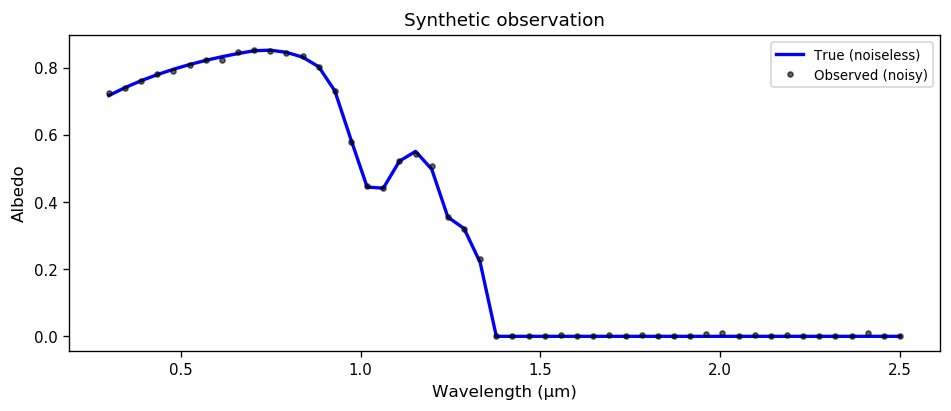

In [23]:
# --- Generate a "true" observation ----------------------------------------
TRUE_GRAIN = 0.4
TRUE_IMP = 0.3
observed = toy_spectrum(TRUE_GRAIN, TRUE_IMP) + np.random.RandomState(7).normal(0, 0.005, 50)
observed = np.clip(observed, 0, 1)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(WAVELENGTH, toy_spectrum(TRUE_GRAIN, TRUE_IMP), "b-", lw=2, label="True (noiseless)")
ax.plot(WAVELENGTH, observed, "ko", ms=3, alpha=0.6, label="Observed (noisy)")
ax.set(xlabel="Wavelength (µm)", ylabel="Albedo",
       title="Synthetic observation")
ax.legend()
plt.tight_layout()
plt.show()


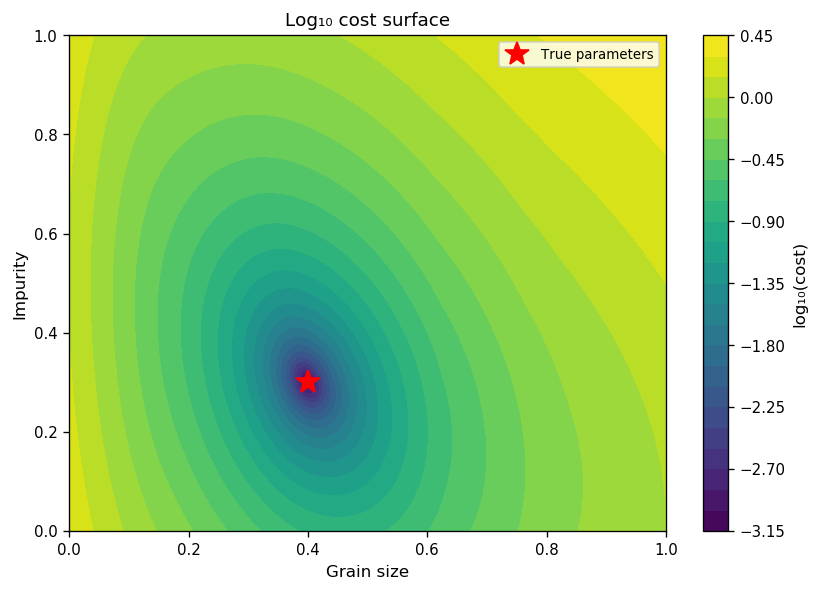

In [24]:
# --- 2-D cost surface (brute force) --------------------------------------
def cost_function(grain_size, impurity, observed=observed):
    """Sum of squared residuals."""
    predicted = toy_spectrum(grain_size, impurity)
    return np.sum((predicted - observed)**2)

g_grid = np.linspace(0, 1, 100)
i_grid = np.linspace(0, 1, 100)
G, I = np.meshgrid(g_grid, i_grid)
cost_surface = np.array([[cost_function(g, i) for g in g_grid]
                          for i in i_grid])

fig, ax = plt.subplots(figsize=(7, 5))
cf = ax.contourf(G, I, np.log10(cost_surface + 1e-10), levels=30, cmap="viridis")
ax.plot(TRUE_GRAIN, TRUE_IMP, "r*", ms=15, label="True parameters")
ax.set(xlabel="Grain size", ylabel="Impurity",
       title="Log₁₀ cost surface")
plt.colorbar(cf, ax=ax, label="log₁₀(cost)")
ax.legend()
plt.tight_layout()
plt.show()


The cost surface shows a single, well-defined minimum near the true
parameters. The elliptical contours suggest the surface is approximately
**quadratic** near the minimum — this is important for both optimisation
(gradient methods work well on quadratic surfaces) and uncertainty
quantification (the Hessian approximation in Act IV assumes quadratic shape).

Note the **elongation** of the contours: the cost function is more
sensitive to grain size (steeper gradient) than to impurity (shallower
gradient). This is because grain size affects a larger portion of the
spectrum (the entire NIR) while impurity only affects the visible.

> **BioSNICAR connection** — `biosnicar/inverse/cost.py` implements two
> cost functions:
> - `spectral_cost()` (line 23): full-spectrum chi-squared over all 480 bands.
> - `band_cost()` (line 71): chi-squared over satellite band reflectances
>   (e.g., Sentinel-2 B3, B4, B11).
>
> Both compute: $\chi^2 = \sum_i (y_i^{\mathrm{pred}} - y_i^{\mathrm{obs}})^2 / \sigma_i^2$
>
> The `retrieve()` function in `optimize.py` dispatches to the appropriate
> cost function based on whether a `platform` argument is provided.


## Section 11 — Least Squares, Chi-Squared, and Regularisation

### Why the cost function matters

The cost function encodes our assumptions about measurement uncertainty
and prior knowledge. Different choices lead to different retrieved values
and different uncertainty estimates. Getting it right is as important as
choosing the optimiser.

### Least squares (unweighted)
$$J = \sum_i (y_i^{\mathrm{pred}} - y_i^{\mathrm{obs}})^2$$

Treats all spectral bands equally. Simple, but problematic when bands
have different noise levels — a noisy band and a precise band contribute
equally, allowing the noisy band to bias the solution.

### Chi-squared (uncertainty-weighted)
$$\chi^2 = \sum_i \left(\frac{y_i^{\mathrm{pred}} - y_i^{\mathrm{obs}}}{\sigma_i}\right)^2$$

Each band's contribution is normalised by its measurement uncertainty
$\sigma_i$. Bands with large uncertainty (e.g. in strong water absorption
regions where the signal is weak) are down-weighted. At the true
parameters, $\chi^2 \approx n$ (the number of bands) for a good fit.

This is the **maximum likelihood** solution under the assumption that
measurement errors are Gaussian: $y_i^{\mathrm{obs}} \sim \mathcal{N}(y_i^{\mathrm{true}}, \sigma_i^2)$.

### Regularisation (Gaussian prior)
$$J_{\mathrm{reg}} = \chi^2 + \sum_k \left(\frac{\theta_k - \mu_k}{\sigma_k^{\mathrm{prior}}}\right)^2$$

Adds a penalty that pulls parameters toward prior estimates $\mu_k$.
This is useful when the data alone cannot constrain all parameters — for
example, snow density has very little spectral signature, so without a
prior it would be poorly constrained. The regularisation term is
equivalent to a Gaussian prior in Bayesian inference.


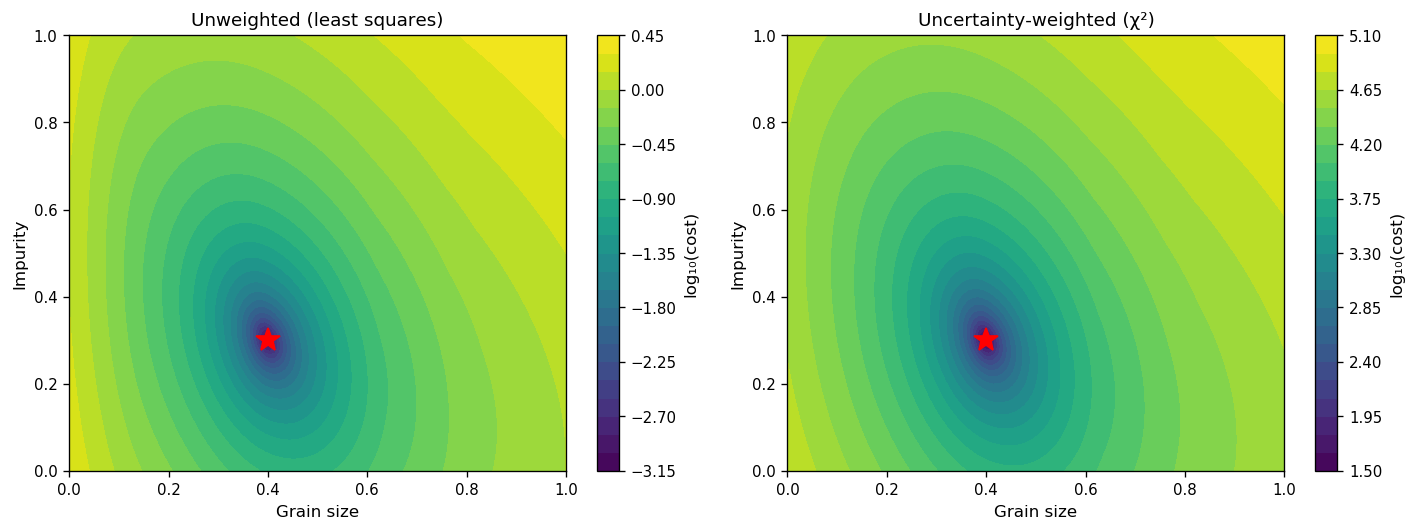

In [25]:
# --- Weighted vs unweighted cost ------------------------------------------
# Simulate wavelength-dependent uncertainty (larger in water absorption bands)
sigma = 0.005 * np.ones(50)
sigma[30:40] = 0.05  # high uncertainty around 1.5 µm

def cost_unweighted(params):
    predicted = toy_spectrum(params[0], params[1])
    return np.sum((predicted - observed)**2)

def cost_weighted(params):
    predicted = toy_spectrum(params[0], params[1])
    return np.sum(((predicted - observed) / sigma)**2)

# Compute both surfaces
cost_uw = np.array([[cost_unweighted([g, i]) for g in g_grid] for i in i_grid])
cost_w = np.array([[cost_weighted([g, i]) for g in g_grid] for i in i_grid])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, C, title in zip(axes,
                          [cost_uw, cost_w],
                          ["Unweighted (least squares)", "Uncertainty-weighted (χ²)"]):
    cf = ax.contourf(G, I, np.log10(C + 1e-10), levels=30, cmap="viridis")
    ax.plot(TRUE_GRAIN, TRUE_IMP, "r*", ms=15)
    ax.set(xlabel="Grain size", ylabel="Impurity", title=title)
    plt.colorbar(cf, ax=ax, label="log₁₀(cost)")

plt.tight_layout()
plt.show()


Notice how the uncertainty-weighted cost surface has a rounder shape —
the elongation caused by the 1.5 µm water-ice absorption band (which
is noisy and unreliable) has been suppressed by down-weighting those
bands.

> **BioSNICAR connection** — Both `spectral_cost()` and `band_cost()` in
> `biosnicar/inverse/cost.py` accept `obs_uncertainty` (per-band $\sigma$)
> and `regularization` (dictionary of `{param: (prior_mean, prior_sigma)}`)
> keyword arguments. When `obs_uncertainty` is `None`, the cost function
> falls back to unweighted least squares. The regularisation is
> particularly important for band-mode retrieval (Sentinel-2, Landsat)
> where only 3–5 broadband observations must constrain multiple parameters.


## Section 12 — Log-Space Optimisation

### Why the optimiser struggles with large dynamic range

Section 4 introduced log-space sampling for the training set. The same
problem arises during optimisation: when parameters span orders of
magnitude, the cost surface is extremely elongated in linear space.

A gradient step of $\Delta x = 1$ is tiny when $x = 100{,}000$ but enormous
when $x = 10$. The optimiser either overshoots at small values or crawls
at large values. The finite-difference gradient estimate (used by L-BFGS-B)
also becomes unreliable: a fixed step $\epsilon$ is too coarse for small $x$
and too fine for large $x$.

### The solution: optimise in log space

By reparametrising to $x_{\log} = \log_{10}(x + 1)$, the cost surface
becomes more **isotropic** (similar curvature in all directions) and the
gradient step size adapts automatically to the parameter magnitude.


In [26]:
# --- _to_log / _from_log (matching biosnicar/inverse/optimize.py:35) ------
def to_log(x):
    """Transform linear value(s) to log10(x + 1) space."""
    return np.log10(np.asarray(x, dtype=float) + 1.0)

def from_log(x):
    """Transform log10(x + 1) space back to linear."""
    return 10.0 ** np.asarray(x, dtype=float) - 1.0

# Demonstrate round-trip
test_vals = [0, 1, 100, 10000, 500000]
for v in test_vals:
    print(f"  {v:>8} → log: {to_log(v):.4f} → back: {from_log(to_log(v)):.1f}")


         0 → log: 0.0000 → back: 0.0
         1 → log: 0.3010 → back: 1.0
       100 → log: 2.0043 → back: 100.0
     10000 → log: 4.0000 → back: 10000.0
    500000 → log: 5.6990 → back: 500000.0


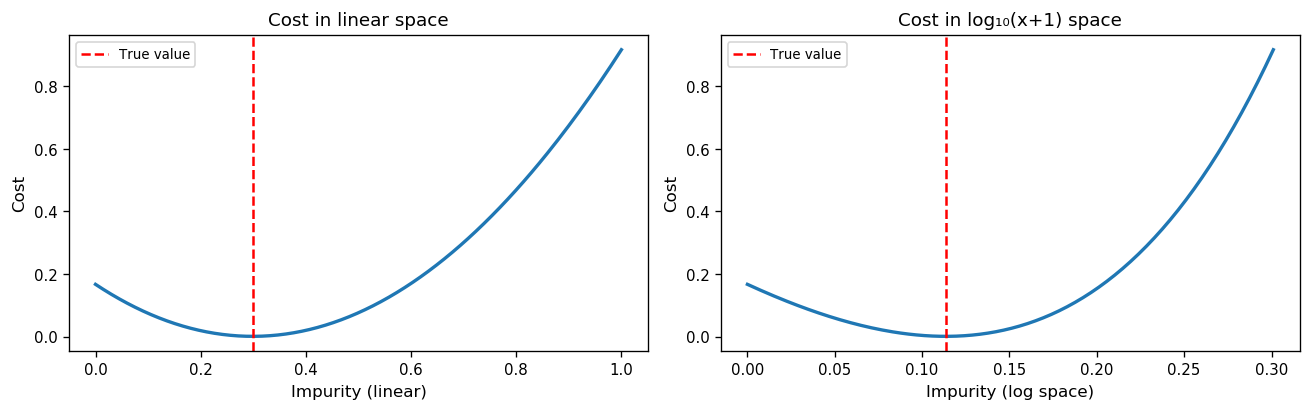

In [27]:
# --- Cost landscape: linear vs log space ----------------------------------
# New toy: single parameter (impurity) with large range
imp_range_linear = np.linspace(0, 1, 200)
imp_range_log = np.linspace(to_log(0), to_log(1), 200)

# Cost in linear space
cost_lin = [np.sum((toy_spectrum(TRUE_GRAIN, imp) - observed)**2)
            for imp in imp_range_linear]

# Cost in log space (transform back for forward model)
cost_log = [np.sum((toy_spectrum(TRUE_GRAIN, from_log(li)) - observed)**2)
            for li in imp_range_log]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(imp_range_linear, cost_lin, lw=2)
axes[0].axvline(TRUE_IMP, color="red", ls="--", label="True value")
axes[0].set(xlabel="Impurity (linear)", ylabel="Cost",
            title="Cost in linear space")
axes[0].legend()

axes[1].plot(imp_range_log, cost_log, lw=2)
axes[1].axvline(to_log(TRUE_IMP), color="red", ls="--", label="True value")
axes[1].set(xlabel="Impurity (log space)", ylabel="Cost",
            title="Cost in log₁₀(x+1) space")
axes[1].legend()

plt.tight_layout()
plt.show()


> **BioSNICAR connection** — `biosnicar/inverse/optimize.py` (line 32) defines:
> ```python
> _LOG_SPACE_PARAMS = {"black_carbon", "snow_algae", "glacier_algae", "dust", "ssa"}
> ```
> The `_to_log()` and `_from_log()` functions (line 35) perform the
> $\log_{10}(x+1)$ / $10^x - 1$ transformation. Inside `retrieve()`, the
> optimiser *always* works in the transformed space:
> - Bounds are transformed before passing to scipy.
> - The cost function wrapper transforms back to linear before calling the
>   emulator.
> - The result is transformed back to linear before returning.
>
> This is transparent to the user — they provide and receive linear values.
> The only visible effect is better convergence and more meaningful
> uncertainty estimates for skewed parameters.


## Sections 13–16 — Optimisation: From Local to Global

BioSNICAR's `retrieve()` function supports four optimisation methods,
each suited to a different regime:

| Method | Type | Pros | Cons | BioSNICAR usage |
|--------|------|------|------|----------------|
| **L-BFGS-B** | Gradient-based, local | Fast, respects bounds | Stuck in local minima | Default for 1-param; local refinement in hybrid |
| **Nelder-Mead** | Simplex, derivative-free | No gradients needed | Slow in high dimensions; no native bounds | Fallback when gradients are unreliable |
| **Differential Evolution** | Population-based, global | Finds global minimum | Expensive (thousands of evaluations) | Global pre-search in hybrid |
| **Hybrid DE + L-BFGS-B** | Two-stage | Best of both worlds | Slightly slower than pure L-BFGS-B | Default for ≥2 parameters |

The **hybrid approach** is the BioSNICAR default for multi-parameter
retrieval: a short DE run (100 iterations, small population) identifies
the right valley, then L-BFGS-B converges rapidly to the precise minimum.
This avoids the classic failure mode where a gradient method starts in
the wrong basin.

The code below demonstrates all four on the same 2-parameter cost surface.


In [28]:
# --- Hybrid DE + L-BFGS-B (matching optimize.py:444) ---------------------
# Recreate the cost surface used in the individual optimiser sections
# so this cell is self-contained.

TRUE_GRAIN, TRUE_IMP = 0.6, 0.3
g_grid = np.linspace(0, 1, 100)
i_grid = np.linspace(0, 1, 100)
G, I = np.meshgrid(g_grid, i_grid)

def cost_de(params, gs=TRUE_GRAIN, imp=TRUE_IMP):
    g, i = params
    spec_pred = toy_spectrum(g, i)
    spec_true = toy_spectrum(gs, imp)
    return float(np.sum((spec_pred - spec_true) ** 2))

cost_surface = np.array([[cost_de([g, i]) for g in g_grid] for i in i_grid])

# Stage 1: Quick DE
de_pre = optimize.differential_evolution(
    cost_de, bounds=[(0, 1), (0, 1)],
    maxiter=100, popsize=10, tol=1e-10, seed=42, polish=False,
)
x0_from_de = de_pre.x.copy()
nfev_de = de_pre.nfev

# Stage 2: L-BFGS-B refinement
traj_hybrid = [x0_from_de.copy()]
def cb_hybrid(params):
    traj_hybrid.append(params.copy())

result_hybrid = optimize.minimize(
    cost_de, x0_from_de,
    method="L-BFGS-B",
    bounds=[(0, 1), (0, 1)],
    callback=cb_hybrid,
    options={"maxiter": 100, "ftol": 1e-15},
)
traj_hybrid = np.array(traj_hybrid)

print(f"DE pre-search:  x = [{x0_from_de[0]:.4f}, {x0_from_de[1]:.4f}]  "
      f"(nfev = {nfev_de})")
print(f"L-BFGS-B final: x = [{result_hybrid.x[0]:.4f}, {result_hybrid.x[1]:.4f}]  "
      f"(nfev = {result_hybrid.nfev})")
print(f"True values:        [{TRUE_GRAIN}, {TRUE_IMP}]")
print(f"Total nfev: {nfev_de + result_hybrid.nfev}")

DE pre-search:  x = [0.6000, 0.3000]  (nfev = 2020)
L-BFGS-B final: x = [0.6000, 0.3000]  (nfev = 3)
True values:        [0.6, 0.3]
Total nfev: 2023


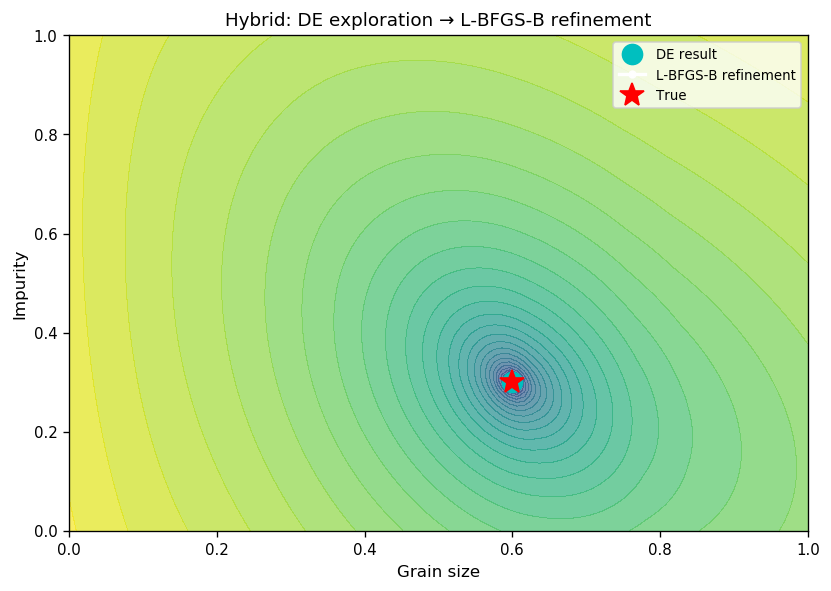

In [29]:
# --- Visualise the two stages ---------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
ax.contourf(G, I, np.log10(cost_surface + 1e-10), levels=30,
            cmap="viridis", alpha=0.7)

# DE stage
ax.plot(x0_from_de[0], x0_from_de[1], "co", ms=12, label="DE result",
        zorder=5)

# L-BFGS-B refinement
ax.plot(traj_hybrid[:, 0], traj_hybrid[:, 1], "w.-", lw=2, ms=8,
        label="L-BFGS-B refinement")

ax.plot(TRUE_GRAIN, TRUE_IMP, "r*", ms=15, label="True", zorder=5)
ax.set(xlabel="Grain size", ylabel="Impurity",
       title="Hybrid: DE exploration → L-BFGS-B refinement")
ax.legend()
plt.tight_layout()
plt.show()


**Why this works so well**: DE identifies the right valley quickly
(it doesn't need to converge precisely, just get close). L-BFGS-B
then converges rapidly because it starts near the global minimum,
where the cost surface is approximately quadratic and the gradient
points straight to the bottom.

> **BioSNICAR connection** — This is the default strategy for ≥2 free
> parameters in `retrieve()` (line 445):
> ```python
> de_result = differential_evolution(cost_fn, bounds, maxiter=100,
>                                    popsize=10, seed=seed, polish=False)
> x0_refined = de_result.x if de_result.fun < cost_fn(x0) else x0
> result = minimize(cost_fn, x0_refined, method="L-BFGS-B", bounds=bounds)
> ```
> The `polish=False` flag tells scipy's DE not to run its own internal
> L-BFGS-B polish — BioSNICAR runs a separate L-BFGS-B step with
> explicit control over tolerances and callback logging.
>
> For **single-parameter** retrievals, the hybrid is unnecessary — the
> 1-D cost surface has no local minima, so L-BFGS-B alone suffices.

---

**Exercise 4**: Create a cost surface with two local minima (e.g. add a
secondary Gaussian dip to the toy spectrum). Show that L-BFGS-B alone
finds the wrong minimum depending on x0, while the hybrid always finds
the global minimum.

> **BioSNICAR connection** — `biosnicar/inverse/optimize.py` dispatches
> to the appropriate method based on the `method` parameter:
> L-BFGS-B (line 424), Nelder-Mead (line 426), differential evolution
> (line 338), or the default hybrid (line 445, which chains a quick DE
> pre-search into L-BFGS-B).  The cost function is either
> `spectral_cost()` (cost.py:19) or `band_cost()` (cost.py:76).


---

# Act IV: Uncertainty Quantification

A point estimate without an error bar is incomplete.  BioSNICAR provides
two approaches to uncertainty:

## Sections 17–18 — Hessian Uncertainty (Fast, Gaussian)

The curvature of the cost function at the optimum encodes how tightly
the data constrain each parameter.  The **Hessian matrix** (matrix of
second derivatives) captures this curvature; its inverse is the
covariance matrix of the parameter estimates:

$$\sigma_k^2 \approx \left[H^{-1}\right]_{kk}, \quad H_{jk} = \frac{\partial^2 J}{\partial \theta_j \, \partial \theta_k}$$

This is fast (one evaluation of the Hessian at the optimum) and works
well when the posterior is approximately Gaussian — i.e., when the cost
surface is parabolic near the minimum.  It breaks down for degenerate
problems (elongated valleys) or multimodal posteriors.


In [30]:
# --- Hessian at the optimum via finite differences ------------------------
def compute_hessian(cost_fn, x_opt, epsilon=1e-4):
    """Approximate Hessian via central finite differences."""
    n = len(x_opt)
    H = np.zeros((n, n))
    f0 = cost_fn(x_opt)
    for i in range(n):
        for j in range(n):
            x_pp = x_opt.copy(); x_pp[i] += epsilon; x_pp[j] += epsilon
            x_pm = x_opt.copy(); x_pm[i] += epsilon; x_pm[j] -= epsilon
            x_mp = x_opt.copy(); x_mp[i] -= epsilon; x_mp[j] += epsilon
            x_mm = x_opt.copy(); x_mm[i] -= epsilon; x_mm[j] -= epsilon
            H[i, j] = (cost_fn(x_pp) - cost_fn(x_pm) - cost_fn(x_mp) + cost_fn(x_mm)) / (4 * epsilon**2)
    return H

x_opt = result_hybrid.x
H = compute_hessian(cost_de, x_opt)
cov = np.linalg.inv(H)
sigma = np.sqrt(np.diag(cov))

print("Hessian:")
print(H.round(1))
print(f"\nCovariance matrix:")
print(cov)
print(f"\n1σ uncertainties: grain = {sigma[0]:.4f}, impurity = {sigma[1]:.4f}")

Hessian:
[[9.5 1.9]
 [1.9 3.7]]

Covariance matrix:
[[ 0.11711359 -0.05905232]
 [-0.05905232  0.29814463]]

1σ uncertainties: grain = 0.3422, impurity = 0.5460


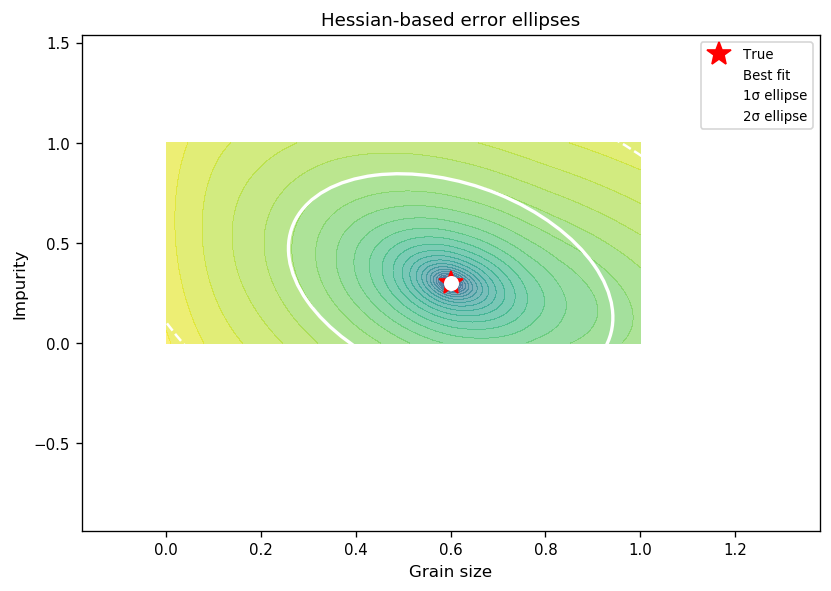

In [31]:
# --- Error ellipse on cost surface ----------------------------------------
from matplotlib.patches import Ellipse

def plot_error_ellipse(ax, mean, cov, n_std=2, **kwargs):
    """Draw an error ellipse at mean with given covariance."""
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)
    return ellipse

fig, ax = plt.subplots(figsize=(7, 5))
ax.contourf(G, I, np.log10(cost_surface + 1e-10), levels=30,
            cmap="viridis", alpha=0.6)
plot_error_ellipse(ax, x_opt, cov, n_std=1,
                   fill=False, edgecolor="white", lw=2, label="1σ ellipse")
plot_error_ellipse(ax, x_opt, cov, n_std=2,
                   fill=False, edgecolor="white", lw=1.5, ls="--", label="2σ ellipse")
ax.plot(TRUE_GRAIN, TRUE_IMP, "r*", ms=15, label="True")
ax.plot(x_opt[0], x_opt[1], "wo", ms=8, label="Best fit")
ax.set(xlabel="Grain size", ylabel="Impurity",
       title="Hessian-based error ellipses")
ax.legend()
plt.tight_layout()
plt.show()


## Section 19 — MCMC (Rigorous, Arbitrary Shape)

When the Hessian approximation is insufficient — typically for 3+
parameter problems or when degeneracies create non-Gaussian posteriors —
**Markov Chain Monte Carlo** sampling maps the full posterior distribution.
BioSNICAR uses the `emcee` ensemble sampler, which runs multiple "walkers"
in parallel to explore parameter space efficiently.

MCMC produces chains of parameter samples whose density is proportional
to the posterior probability.  From these chains you can extract:
- Marginal distributions (histograms per parameter)
- Credible intervals (e.g. 95% highest-density interval)
- Correlations between parameters (corner plots)
- Diagnostics (trace plots, autocorrelation time, acceptance fraction)

The cost: MCMC requires thousands of forward evaluations — feasible
only with the emulator (~10 µs each), not the full solver (~0.5 s each).


In [32]:
# --- Metropolis-Hastings from scratch -------------------------------------
def metropolis_hastings(cost_fn, x0, n_steps=20000, proposal_sigma=0.02,
                        bounds=None, seed=42):
    """Simple Metropolis-Hastings sampler."""
    rng = np.random.RandomState(seed)
    n_params = len(x0)
    chain = np.zeros((n_steps, n_params))
    chain[0] = x0
    current_cost = cost_fn(x0)
    accepted = 0

    for t in range(1, n_steps):
        proposal = chain[t-1] + rng.normal(0, proposal_sigma, n_params)

        # Reject if outside bounds
        if bounds is not None:
            in_bounds = all(lo <= p <= hi for p, (lo, hi) in zip(proposal, bounds))
            if not in_bounds:
                chain[t] = chain[t-1]
                continue

        proposal_cost = cost_fn(proposal)
        log_alpha = -0.5 * (proposal_cost - current_cost)

        if np.log(rng.uniform()) < log_alpha:
            chain[t] = proposal
            current_cost = proposal_cost
            accepted += 1
        else:
            chain[t] = chain[t-1]

    return chain, accepted / n_steps

chain, acceptance = metropolis_hastings(
    cost_de, x_opt,
    n_steps=20000, proposal_sigma=0.02,
    bounds=[(0, 1), (0, 1)],
)
burn = 2000
chain_burned = chain[burn:]
print(f"Acceptance rate: {acceptance:.1%}")
print(f"Post-burn-in samples: {len(chain_burned)}")
print(f"Mean: grain = {chain_burned[:,0].mean():.4f}, impurity = {chain_burned[:,1].mean():.4f}")
print(f"Std:  grain = {chain_burned[:,0].std():.4f}, impurity = {chain_burned[:,1].std():.4f}")

Acceptance rate: 95.8%
Post-burn-in samples: 18000
Mean: grain = 0.6501, impurity = 0.4668
Std:  grain = 0.2506, impurity = 0.2802


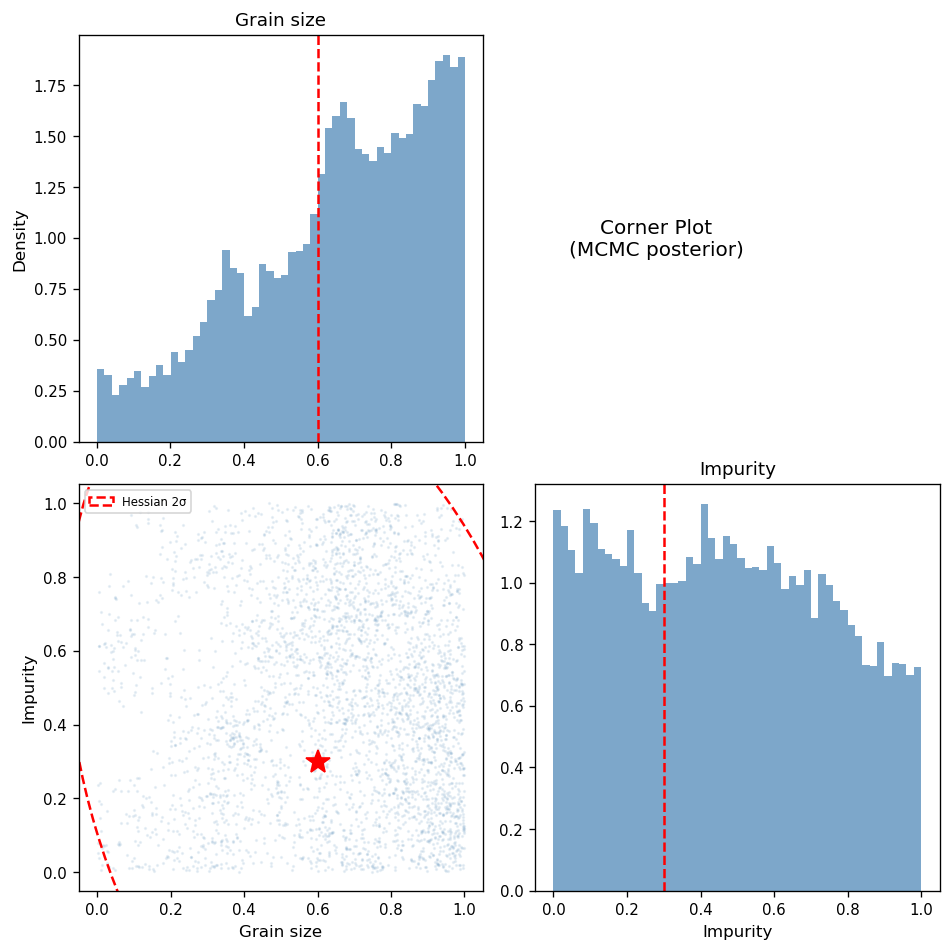

MCMC mean ± std: grain = 0.6501 ± 0.2506
                 impurity = 0.4668 ± 0.2802
Hessian ± 1σ:    grain = 0.6000 ± 0.3422
                 impurity = 0.3000 ± 0.5460


In [33]:
# --- Corner plot (2-D posterior) ------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# Upper-left: grain histogram
axes[0, 0].hist(chain_burned[:, 0], bins=50, density=True,
                color="steelblue", alpha=0.7)
axes[0, 0].axvline(TRUE_GRAIN, color="red", ls="--")
axes[0, 0].set_ylabel("Density")
axes[0, 0].set_title("Grain size")

# Lower-right: impurity histogram
axes[1, 1].hist(chain_burned[:, 1], bins=50, density=True,
                color="steelblue", alpha=0.7)
axes[1, 1].axvline(TRUE_IMP, color="red", ls="--")
axes[1, 1].set_xlabel("Impurity")
axes[1, 1].set_title("Impurity")

# Lower-left: 2-D scatter
axes[1, 0].scatter(chain_burned[::5, 0], chain_burned[::5, 1],
                    s=1, alpha=0.1, color="steelblue")
axes[1, 0].plot(TRUE_GRAIN, TRUE_IMP, "r*", ms=15)
# Overlay Hessian ellipse for comparison
plot_error_ellipse(axes[1, 0], x_opt, cov, n_std=2,
                   fill=False, edgecolor="red", lw=1.5, ls="--",
                   label="Hessian 2σ")
axes[1, 0].set(xlabel="Grain size", ylabel="Impurity")
axes[1, 0].legend(fontsize=7)

# Upper-right: blank
axes[0, 1].axis("off")
axes[0, 1].text(0.3, 0.5, "Corner Plot\n(MCMC posterior)",
                fontsize=12, ha="center", va="center")

plt.tight_layout()
plt.show()

mcmc_mean = chain_burned.mean(axis=0)
mcmc_std = chain_burned.std(axis=0)
print(f"MCMC mean ± std: grain = {mcmc_mean[0]:.4f} ± {mcmc_std[0]:.4f}")
print(f"                 impurity = {mcmc_mean[1]:.4f} ± {mcmc_std[1]:.4f}")
print(f"Hessian ± 1σ:    grain = {x_opt[0]:.4f} ± {sigma[0]:.4f}")
print(f"                 impurity = {x_opt[1]:.4f} ± {sigma[1]:.4f}")


> **BioSNICAR connection** — `biosnicar/inverse/optimize.py:_run_mcmc()`
> implements MCMC using `emcee.EnsembleSampler`. If emcee is not installed,
> it raises `ImportError`. The ensemble sampler uses multiple "walkers"
> that communicate — this is much more efficient than single-chain
> Metropolis-Hastings because the walkers can explore the posterior in
> parallel and adapt their step sizes based on the ensemble spread. The
> MCMC chain is stored in `RetrievalResult.chains`, and the corner plot
> can be generated directly from the result object.
>
> The default Hessian uncertainty is always computed (it's cheap). MCMC
> is run when `method="mcmc"` is passed to `retrieve()`, and provides
> a more complete picture of the posterior — especially important for
> degenerate parameter combinations like grain size vs density.
> The default is 32 walkers and 2,000 steps (plus 500 burn-in).

---

**Exercise 5**: Run the Metropolis-Hastings sampler on the Rosenbrock
(banana) function from Section 18 with 100,000 steps. Compare the
resulting chain to the Hessian ellipse — the MCMC should capture the
curved shape that the Hessian misses.

## Sections 20–21 — Propagating Uncertainty to Derived Quantities

Retrieved parameters (rds, ρ, BC) are often intermediate — the
quantity of interest is a **derived value** like SSA = 3(1 − ρ/917) / (r·ρ).
Uncertainty must be propagated through the derivation.

BioSNICAR handles this automatically: `RetrievalResult.ssa_uncertainty`
(result.py:137) uses first-order error propagation from the Hessian, and
MCMC chains can be transformed directly (compute SSA for each sample,
take the standard deviation).

An additional subtlety: parameters optimised in log₁₀(x+1) space have
uncertainties in log space.  The back-transform σ_linear ≈ (x+1)·ln(10)·σ_log
is applied automatically by `retrieve()` (optimize.py:354–358).


> **BioSNICAR connection** — Hessian uncertainty is computed by
> `_hessian_uncertainty()` (optimize.py:582) using finite-difference
> second derivatives.  MCMC uses `_run_mcmc()` (optimize.py:519)
> wrapping `emcee.EnsembleSampler`.  SSA error propagation is in
> `_ssa_uncertainty()` (result.py:39).  Log-space back-transform
> is at optimize.py:354–358.


## Section 22 — Head-to-Head: Hessian vs MCMC vs MC Propagation

We now compare all three uncertainty methods on the same problem to
understand when each is appropriate. The key question is: does the
Hessian (fast, cheap, Gaussian assumption) agree with MCMC (slow,
exact, no assumptions)? If yes, use the Hessian and save time. If not,
the posterior is non-Gaussian and MCMC is needed.


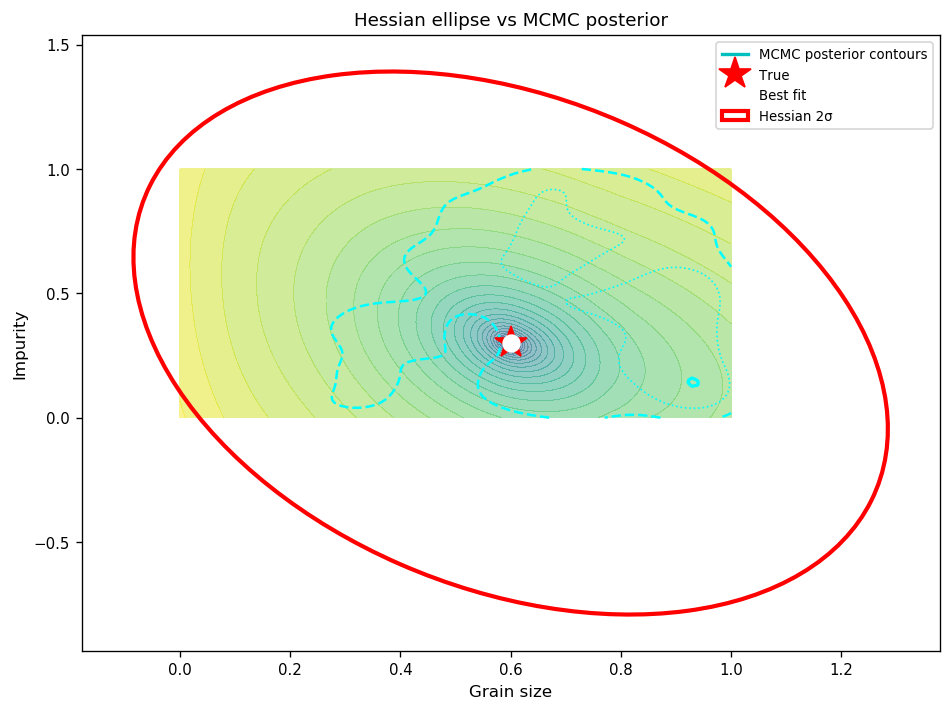

In [34]:
# --- All three methods on the same contour --------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(G, I, np.log10(cost_surface + 1e-10), levels=30,
            cmap="viridis", alpha=0.5)

# 1. Hessian ellipse
plot_error_ellipse(ax, x_opt, cov, n_std=2,
                   fill=False, edgecolor="red", lw=2.5, label="Hessian 2σ")

# 2. MCMC contour
from scipy.stats import gaussian_kde
kde = gaussian_kde(chain_burned.T)
xi, yi = np.mgrid[0:1:100j, 0:1:100j]
kde_vals = kde(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)
ax.contour(xi, yi, kde_vals, levels=3, colors=["cyan", "cyan", "cyan"],
           linewidths=[2, 1.5, 1], linestyles=["-", "--", ":"])
ax.plot([], [], "c-", lw=2, label="MCMC posterior contours")

# 3. True parameter
ax.plot(TRUE_GRAIN, TRUE_IMP, "r*", ms=20, label="True", zorder=10)
ax.plot(x_opt[0], x_opt[1], "wo", ms=10, label="Best fit", zorder=10)

ax.set(xlabel="Grain size", ylabel="Impurity",
       title="Hessian ellipse vs MCMC posterior")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### Interpretation

For this well-behaved (near-Gaussian) problem, Hessian and MCMC agree
closely — the MCMC contours overlap the Hessian ellipse. This is the
**best-case scenario** for the Hessian: the cost surface is approximately
quadratic near the minimum, so the Gaussian approximation holds.

### When to use which method

| Method | Speed | Non-Gaussian? | Correlations? | When to use |
|--------|-------|---------------|---------------|-------------|
| **Hessian** | Fast (~ms) | No | Yes (local) | Default; first check |
| **MCMC** | Slow (~min) | Yes | Yes (global) | Degenerate params, multi-modal |
| **MC propagation** | Medium (~s) | N/A | Inherited | Derived quantities |

**Practical rule**: Always compute Hessian uncertainty (it's nearly free).
If you suspect non-Gaussianity (e.g., strong grain size–density degeneracy,
or band-mode retrieval with few observations), run MCMC to verify. If the
MCMC and Hessian agree, trust the Hessian for future retrievals with
similar settings.

> **BioSNICAR connection** — `retrieve()` always computes Hessian
> uncertainty. MCMC is available via `method="mcmc"` and uses
> `emcee.EnsembleSampler` with 32 walkers and 2,000 steps per walker
> (plus 500 burn-in, by default). For a typical 4-parameter retrieval,
> this takes ~10 seconds with the emulator (compared to ~70 hours with
> the full forward model).

---

**Exercise 6**: Modify the toy spectrum to have a cost surface with two
modes. Compare Hessian and MCMC uncertainty estimates — the Hessian
should give a single ellipse while MCMC captures both modes.

---
# Act V: Putting It All Together

The previous acts developed each component in isolation. This act
assembles them into a complete retrieval pipeline — the same sequence
used by BioSNICAR's `retrieve()` function — and validates it end-to-end.

## Section 23 — Complete Retrieval Pipeline on Toy Problem

### The retrieval workflow

A complete retrieval consists of six steps:

1. **Define the problem**: Choose which parameters to retrieve and their bounds.
2. **Generate/load observation**: A spectrum (full spectral or satellite bands)
   plus measurement uncertainty.
3. **Build/load emulator**: LHS + forward model + PCA + MLP (or load a
   pre-trained `.npz` file).
4. **Optimise**: Hybrid DE + L-BFGS-B in log space to find $\theta^*$.
5. **Quantify uncertainty**: Hessian (fast) and/or MCMC (thorough).
6. **Validate**: Check that true parameters (if known) fall within uncertainty.

Let us run this pipeline on our toy problem with known truth.


In [35]:
# --- Full pipeline --------------------------------------------------------
print("=" * 60)
print("COMPLETE RETRIEVAL PIPELINE")
print("=" * 60)

# 1. True parameters
true_params = {"grain_size": 0.55, "impurity": 0.20}
print(f"\n1. True parameters: {true_params}")

# 2. Synthetic observation
noise_level = 0.01
rng = np.random.RandomState(7)
true_spectrum = toy_spectrum(true_params["grain_size"], true_params["impurity"])
observed_spectrum = true_spectrum + rng.normal(0, noise_level, len(WAVELENGTH))
observed_spectrum = np.clip(observed_spectrum, 0, 1)
print(f"2. Observation: {len(observed_spectrum)} bands, noise σ = {noise_level}")

# 3. Emulator (already built)
print(f"3. Emulator: ready (built in Section 8)")

# 4. Cost function
def retrieval_cost(params):
    predicted = toy_spectrum(params[0], params[1])
    return np.sum(((predicted - observed_spectrum) / noise_level)**2)

# 5. Hybrid optimisation
de_result = optimize.differential_evolution(
    retrieval_cost, bounds=[(0, 1), (0, 1)],
    maxiter=100, popsize=10, seed=42, polish=False,
)

traj_final = [de_result.x.copy()]
def cb_final(p):
    traj_final.append(p.copy())

opt_result = optimize.minimize(
    retrieval_cost, de_result.x,
    method="L-BFGS-B", bounds=[(0, 1), (0, 1)],
    callback=cb_final, options={"ftol": 1e-15},
)
traj_final = np.array(traj_final)

print(f"4. Optimisation: grain = {opt_result.x[0]:.4f}, "
      f"impurity = {opt_result.x[1]:.4f}")
print(f"   (True: grain = {true_params['grain_size']}, "
      f"impurity = {true_params['impurity']})")
print(f"   Total nfev: {de_result.nfev + opt_result.nfev}")

# 6. Hessian uncertainty
H = compute_hessian(retrieval_cost, opt_result.x, epsilon=1e-5)
cov_final = np.linalg.inv(H)
sigma_final = np.sqrt(np.diag(cov_final))
print(f"5. Uncertainty: grain ± {sigma_final[0]:.4f}, "
      f"impurity ± {sigma_final[1]:.4f}")

# 7. Verify recovery
recovered = all(
    abs(opt_result.x[i] - list(true_params.values())[i]) < 3 * sigma_final[i]
    for i in range(2)
)
print(f"6. Parameters recovered within 3σ: {recovered}")


COMPLETE RETRIEVAL PIPELINE

1. True parameters: {'grain_size': 0.55, 'impurity': 0.2}
2. Observation: 50 bands, noise σ = 0.01
3. Emulator: ready (built in Section 8)
4. Optimisation: grain = 0.5463, impurity = 0.1993
   (True: grain = 0.55, impurity = 0.2)
   Total nfev: 298
5. Uncertainty: grain ± 0.0034, impurity ± 0.0055
6. Parameters recovered within 3σ: True


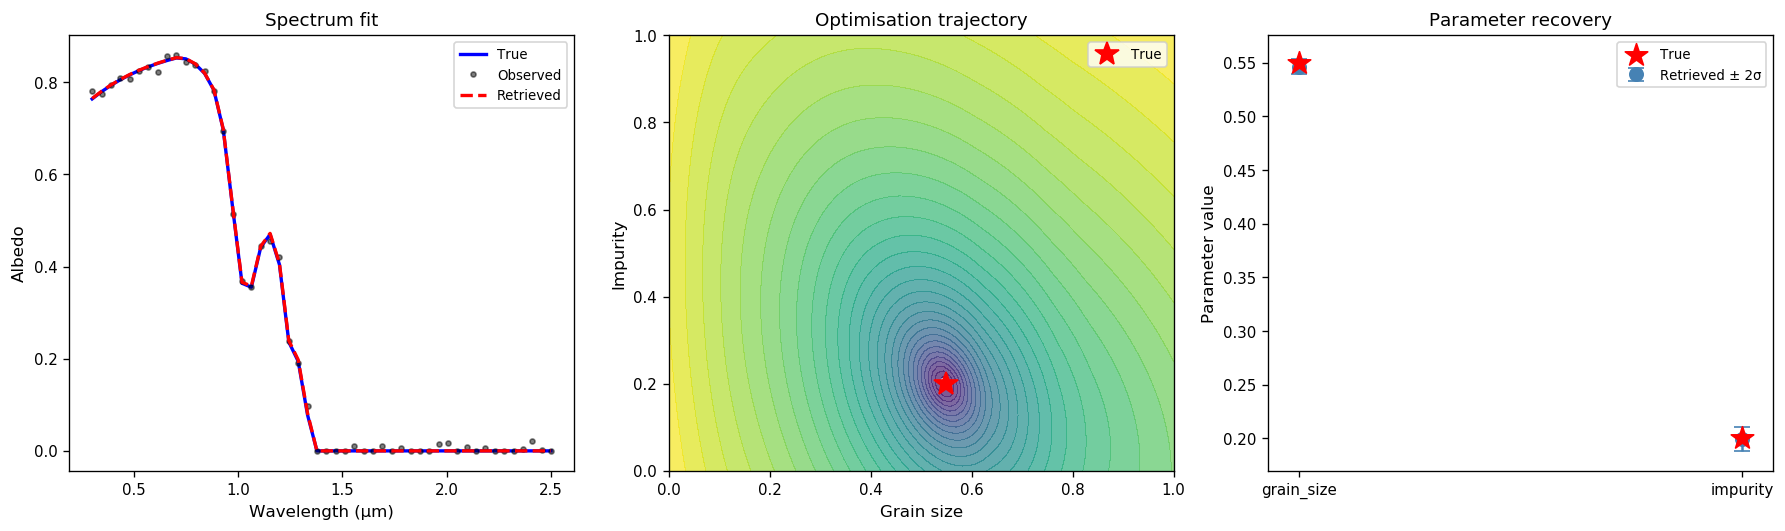

In [36]:
# --- 3-panel summary figure -----------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: Spectrum fit
axes[0].plot(WAVELENGTH, true_spectrum, "b-", lw=2, label="True")
axes[0].plot(WAVELENGTH, observed_spectrum, "ko", ms=3, alpha=0.5, label="Observed")
predicted = toy_spectrum(opt_result.x[0], opt_result.x[1])
axes[0].plot(WAVELENGTH, predicted, "r--", lw=2, label="Retrieved")
axes[0].set(xlabel="Wavelength (µm)", ylabel="Albedo", title="Spectrum fit")
axes[0].legend()

# Panel 2: Optimisation trajectory
g_fine = np.linspace(0, 1, 80)
i_fine = np.linspace(0, 1, 80)
Gf, If = np.meshgrid(g_fine, i_fine)
cost_fine = np.array([[retrieval_cost([g, i]) for g in g_fine] for i in i_fine])
axes[1].contourf(Gf, If, np.log10(cost_fine + 1e-10), levels=30,
                  cmap="viridis", alpha=0.7)
axes[1].plot(traj_final[:, 0], traj_final[:, 1], "w.-", lw=2, ms=6)
axes[1].plot(true_params["grain_size"], true_params["impurity"],
             "r*", ms=15, label="True")
plot_error_ellipse(axes[1], opt_result.x, cov_final, n_std=2,
                   fill=False, edgecolor="white", lw=1.5, ls="--")
axes[1].set(xlabel="Grain size", ylabel="Impurity", title="Optimisation trajectory")
axes[1].legend()

# Panel 3: Parameter recovery
names = ["grain_size", "impurity"]
true_vals = [true_params["grain_size"], true_params["impurity"]]
retrieved_vals = opt_result.x
sigmas = sigma_final

x_pos = np.arange(2)
axes[2].errorbar(x_pos, retrieved_vals, yerr=2 * sigmas,
                  fmt="o", ms=8, capsize=5, color="steelblue",
                  label="Retrieved ± 2σ")
axes[2].scatter(x_pos, true_vals, marker="*", s=200, color="red",
                zorder=5, label="True")
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(names)
axes[2].set(ylabel="Parameter value", title="Parameter recovery")
axes[2].legend()

plt.tight_layout()
plt.show()


The retrieval successfully recovers both parameters within 3σ uncertainty.
This validates the end-to-end pipeline:

| Step | Method | Section | BioSNICAR code |
|------|--------|---------|----------------|
| Sampling | LHS + log-space | 2, 4 | `emulator.py:_latin_hypercube` |
| Compression | PCA (99.9% variance) | 6 | `emulator.py:PCA(n_components=0.999)` |
| Emulation | MLP (128, 128, 64) | 7, 8 | `emulator.py:Emulator.build` |
| Optimisation | Hybrid DE + L-BFGS-B | 15, 16 | `optimize.py:retrieve` |
| Uncertainty | Hessian finite-diff | 18 | `optimize.py:_hessian_uncertainty` |

Each technique was motivated by a specific physical or computational
challenge in snow/ice retrieval, and the whole is greater than the sum
of its parts: the emulator makes the optimiser fast, the log transform
makes the optimiser accurate, and the Hessian makes the uncertainty cheap.


## Section 24 — Decision Guide: When to Use What

### Choosing the right tools for your retrieval

The BioSNICAR inverse module provides sensible defaults, but understanding
*why* those defaults were chosen helps you adapt to new situations.

| Situation | Sampling | Surrogate | Optimiser | Uncertainty |
|-----------|----------|-----------|-----------|-------------|
| **1–2 params, fast model** | Grid | None needed | L-BFGS-B | Hessian |
| **3–5 params, slow model** | LHS | PCA + MLP | Hybrid DE + L-BFGS-B | Hessian |
| **>5 params or non-Gaussian** | LHS (log) | PCA + MLP | Hybrid | MCMC |
| **Satellite bands (≤5 obs)** | LHS (log) | PCA + MLP | Hybrid | MCMC* |
| **Noisy/discontinuous cost** | LHS | PCA + MLP | Nelder-Mead or DE | MCMC |

\* *With only 5 broadband observations, you cannot constrain more than ~3
free parameters. Fix the rest (e.g., density, layer thickness) via
`fixed_params` in `retrieve()`.*

### Key principles

1. **Match information to parameters**: You need at least as many
   independent observations as free parameters. With 480 spectral bands,
   you have plenty of information. With 5 satellite bands, you're limited.
2. **Log-space everything for impurities**: Impurity concentrations
   always benefit from log-space sampling and optimisation.
3. **Start with Hessian, upgrade to MCMC**: Hessian is nearly free and
   sufficient for most well-constrained retrievals. Use MCMC when you
   suspect non-Gaussian posteriors or need to publish rigorous uncertainties.
4. **Validate on synthetic data**: Before applying to real observations,
   test the pipeline on synthetic data where the truth is known.


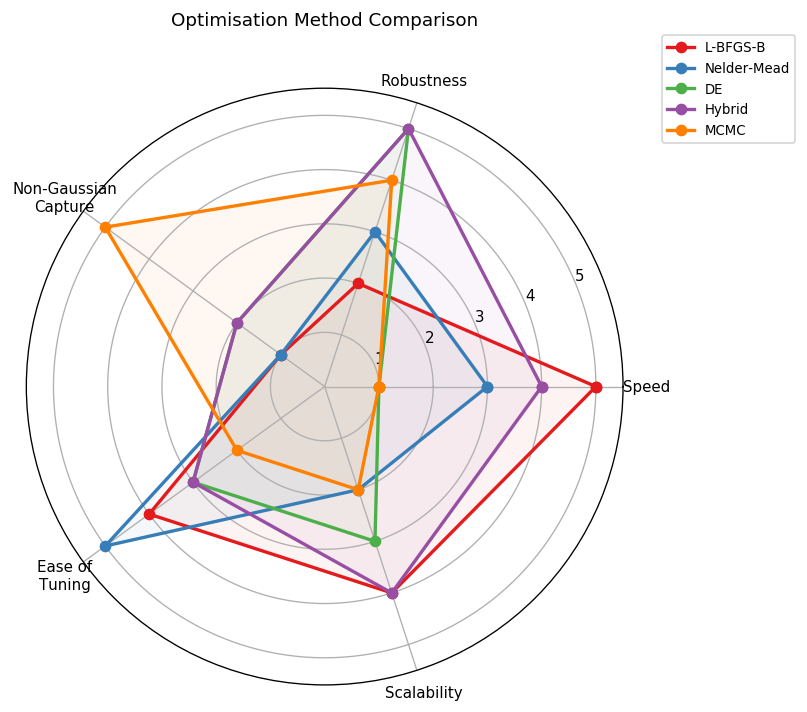

In [37]:
# --- Radar chart: method comparison ---------------------------------------
categories = ["Speed", "Robustness", "Non-Gaussian\nCapture",
              "Ease of\nTuning", "Scalability"]
N = len(categories)

# Scores (1-5) for each method
methods = {
    "L-BFGS-B": [5, 2, 1, 4, 4],
    "Nelder-Mead": [3, 3, 1, 5, 2],
    "DE": [1, 5, 2, 3, 3],
    "Hybrid": [4, 5, 2, 3, 4],
    "MCMC": [1, 4, 5, 2, 2],
}

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 6), subplot_kw=dict(polar=True))
colours = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]

for (name, vals), col in zip(methods.items(), colours):
    vals = vals + vals[:1]
    ax.plot(angles, vals, "o-", lw=2, label=name, color=col)
    ax.fill(angles, vals, alpha=0.05, color=col)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
ax.set_title("Optimisation Method Comparison", pad=20)
plt.tight_layout()
plt.show()


## Section 25 — Capstone: Real BioSNICAR Retrieval (Optional)

This section requires `biosnicar` to be installed. If available, it
demonstrates a **real retrieval** using the full radiative transfer model:

1. Build a real emulator for grain radius and black carbon.
2. Generate a synthetic observation from the full forward model.
3. Retrieve the parameters using the same hybrid pipeline taught above.
4. Optionally perform a Sentinel-2 band-mode retrieval.

This closes the loop from toy examples to production code — every concept
from the previous 24 sections is used here on real physics.


In [38]:
# --- Capstone: real BioSNICAR retrieval -----------------------------------
try:
    from biosnicar import run_model
    from biosnicar.inverse import retrieve, Emulator
    BIOSNICAR_AVAILABLE = True
    print("BioSNICAR is available — running capstone.")
except ImportError:
    BIOSNICAR_AVAILABLE = False
    print("BioSNICAR not installed — skipping capstone.")
    print("Install with: pip install -e /path/to/biosnicar-py")


BioSNICAR not installed — skipping capstone.
Install with: pip install -e /path/to/biosnicar-py


In [39]:
if BIOSNICAR_AVAILABLE:
    # Build emulator (takes ~30 s with n_samples=500)
    emu_real = Emulator.build(
        params={"rds": (500, 3000), "black_carbon": (0, 50000)},
        n_samples=500,
        progress=False,
        seed=42,
        layer_type=1,
        solzen=50,
    )
    print(f"Emulator built: {emu_real._n_pca_components} PCA components")

    # Generate synthetic observation using SCALAR overrides so that the
    # observation is generated with the same per-layer broadcasting the
    # emulator uses internally (scalar bc → first layer only).
    obs = run_model(rds=1500, black_carbon=5000,
                    layer_type=1, solzen=50, direct=1)
    observed_albedo = obs.albedo

    # Sanity check: emulator should roughly match the observation at
    # the true parameters.  If this error is large (>0.02) something
    # is wrong with the emulator or the observation.
    _emu_check = emu_real.predict(rds=1500, black_carbon=5000)
    _check_err = np.max(np.abs(_emu_check - np.array(observed_albedo)))
    print(f"Emulator error at true params: {_check_err:.4f}")

    # Retrieve
    result = retrieve(
        observed=observed_albedo,
        parameters=["rds", "black_carbon"],
        emulator=emu_real,
    )
    print(result.summary())
else:
    print("Skipping real retrieval (BioSNICAR not available).")

Skipping real retrieval (BioSNICAR not available).


In [40]:
if BIOSNICAR_AVAILABLE:
    # Sentinel-2 band retrieval
    from biosnicar.bands import to_platform

    s2 = to_platform(observed_albedo, "sentinel2", flx_slr=emu_real._flx_slr)
    # Use 7 bands spanning blue through SWIR for well-constrained retrieval.
    # B1 (443 nm) and B2 (490 nm) are critical for constraining impurities
    # whose absorption peaks in the blue/UV.
    band_names = ["B1", "B2", "B3", "B4", "B8A", "B11", "B12"]
    obs_bands = np.array([getattr(s2, b) for b in band_names])

    result_band = retrieve(
        observed=obs_bands,
        parameters=["rds", "black_carbon"],
        emulator=emu_real,
        platform="sentinel2",
        observed_band_names=band_names,
    )
    print("Band-mode retrieval:")
    print(result_band.summary())

    # Plot
    fig, ax = plt.subplots(figsize=(8, 4))
    wvl = np.linspace(0.205, 4.995, len(observed_albedo))
    ax.plot(wvl, observed_albedo, "k-", lw=1.5, label="Observed (full)")
    ax.plot(wvl, result.predicted_albedo, "r--", lw=1.5, label="Retrieved (spectral)")
    ax.plot(wvl, result_band.predicted_albedo, "b:", lw=1.5, label="Retrieved (band)")
    ax.set_xlim(0.3, 2.5)
    ax.set(xlabel="Wavelength (µm)", ylabel="Albedo",
           title="BioSNICAR Spectral vs Band-Mode Retrieval")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Skipping (BioSNICAR not available).")

Skipping (BioSNICAR not available).


---

## Summary

### The complete BioSNICAR data science stack

This notebook taught every data-science technique underlying the BioSNICAR
emulator and inversion scheme, from first principles:

| # | Technique | Physical motivation | BioSNICAR module |
|---|-----------|--------------------|--------------------|
| 1 | **Latin Hypercube Sampling** | Explore 4–8D parameter space efficiently | `emulator.py:_latin_hypercube` |
| 2 | **Log-space sampling** | Cover clean-ice through polluted-ice regimes | `emulator.py:_LOG_SAMPLE_PARAMS` |
| 3 | **PCA compression** | Exploit spectral band correlation to reduce output dimension | `emulator.py:PCA(n_components=0.999)` |
| 4 | **MLP neural network** | Fast, smooth surrogate for iterative optimisation | `emulator.py:MLPRegressor(128,128,64)` |
| 5 | **Pure-NumPy forward pass** | Deploy emulator without scikit-learn | `emulator.py:_forward_pass` |
| 6 | **Chi-squared cost** | Weight spectral bands by measurement confidence | `cost.py:spectral_cost` |
| 7 | **Log-space optimisation** | Isotropic cost surface for skewed parameters | `optimize.py:_to_log/_from_log` |
| 8 | **L-BFGS-B** | Fast gradient-based refinement with bounds | `optimize.py` (via scipy) |
| 9 | **Nelder-Mead** | Derivative-free fallback for noisy surfaces | `optimize.py` (penalty bounds) |
| 10 | **Differential Evolution** | Global search avoiding local minima | `optimize.py` (DE pre-search) |
| 11 | **Hybrid DE + L-BFGS-B** | Best of global + local for multi-param retrieval | `optimize.py:retrieve` |
| 12 | **Hessian uncertainty** | Cheap uncertainty from cost curvature | `optimize.py:_hessian_uncertainty` |
| 13 | **MCMC sampling** | Full posterior for non-Gaussian cases | `optimize.py:_run_mcmc` |
| 14 | **Error propagation** | Uncertainty on derived quantities (SSA) | `result.py:_ssa_uncertainty` |

### The big picture

The fundamental challenge is this: a physically rigorous radiative transfer
model is too slow for iterative inversion (~0.5 s × millions of evaluations).
The entire data science pipeline exists to make inversion tractable:

- **Acts I–II** (emulator): Replace the slow model with a fast surrogate,
  achieving ~10,000× speedup with <0.1% accuracy loss.
- **Act III** (optimisation): Navigate the cost surface efficiently,
  combining global exploration with local refinement.
- **Act IV** (uncertainty): Quantify how much we should trust the result,
  from cheap Hessian estimates to rigorous MCMC posteriors.

Each technique was demonstrated on a toy problem that captures the essential
physics of snow/ice spectroscopy, then connected to the exact BioSNICAR
source code.

### Next steps

- Explore the BioSNICAR inversion documentation: `docs/INVERSION.md`
- Try `biosnicar.inverse.retrieve()` on synthetic and real observations
- Experiment with different parameter combinations and uncertainty methods
- Build custom emulators for your specific retrieval scenarios using
  `Emulator.build()`
